# Machine Learning 
# COSC 2673 
# Assignment 2
# By Janvi Rathi (3983207)

## Introduction
This project develops machine learning models to analyze histopathology images (27×27 RGB) from colon tissue samples, performing two classification tasks: identifying cancerous cells and determining specific cell types (fibroblast, inflammatory, epithelial, or others). Using a modified CRCHistoPhenotypes dataset from 99 patients with partial labeling, the team progresses from baseline models to advanced CNNs and implements semi-supervised learning to leverage unlabeled data. The comprehensive evaluation demonstrates significant improvement in cell type classification accuracy and offers insights into model robustness across varying image quality conditions.

In [431]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import random
from collections import Counter
from sklearn.utils import class_weight
import skimage.measure as measure
from skimage.filters import threshold_otsu
from sklearn.metrics import f1_score, precision_score, recall_score
from tqdm import tqdm  
import concurrent.futures
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
%matplotlib inline
np.random.seed(42)
tf.random.set_seed(42)

## Approach 
###  1.1 Data Exploration and Understanding 

In [434]:
base_path = "Image_classification_data"
main_data_path = os.path.join(base_path, "data_labels_mainData.csv")
extra_data_path = os.path.join(base_path, "data_labels_extraData.csv")
images_path = os.path.join(base_path, "patch_images")

In [232]:
main_df = pd.read_csv(main_data_path)
extra_df = pd.read_csv(extra_data_path)

In [234]:
print("Main dataset shape:", main_df.shape)
print("Extra dataset shape:", extra_df.shape)
print("Total images:", len(main_df) + len(extra_df))

Main dataset shape: (9896, 6)
Extra dataset shape: (10384, 4)
Total images: 20280


In [236]:
print("\nMissing values in main dataset:")
print(main_df.isnull().sum())
print("\nMissing values in extra dataset:")
print(extra_df.isnull().sum())


Missing values in main dataset:
InstanceID      0
patientID       0
ImageName       0
cellTypeName    0
cellType        0
isCancerous     0
dtype: int64

Missing values in extra dataset:
InstanceID     0
patientID      0
ImageName      0
isCancerous    0
dtype: int64


No misisng values were found in both the datasets

In [238]:
print("\nCell type distribution:")
cell_type_counts = main_df['cellTypeName'].value_counts()
print(cell_type_counts)

cell_type_percentage = (cell_type_counts / len(main_df)) * 100
print("\nCell type percentage distribution:")
print(cell_type_percentage)


Cell type distribution:
cellTypeName
epithelial      4079
inflammatory    2543
fibroblast      1888
others          1386
Name: count, dtype: int64

Cell type percentage distribution:
cellTypeName
epithelial      41.218674
inflammatory    25.697251
fibroblast      19.078416
others          14.005659
Name: count, dtype: float64


The cell type distribution within the main dataset indicates that epithelial cells are the most common (n=4079), followed by inflammatory (n=2543), fibroblast (n=1888), and others (n=1386)

#### Class Imbalance Identification 

In [240]:
print("\nCancer class distribution in main data:")
cancer_counts_main = main_df['isCancerous'].value_counts()
print(cancer_counts_main)
print((cancer_counts_main / len(main_df)) * 100)
print("\nCancer class distribution in extra data:")
cancer_counts_extra = extra_df['isCancerous'].value_counts()
print(cancer_counts_extra)
print((cancer_counts_extra / len(extra_df)) * 100)


Cancer class distribution in main data:
isCancerous
0    5817
1    4079
Name: count, dtype: int64
isCancerous
0    58.781326
1    41.218674
Name: count, dtype: float64

Cancer class distribution in extra data:
isCancerous
0    7394
1    2990
Name: count, dtype: int64
isCancerous
0    71.205701
1    28.794299
Name: count, dtype: float64


About 41% of the samples in the primary dataset are cancerous, while 59% are non-cancerous, indicating a well balanced mix of cancerous and non-cancerous samples. The extra data, however, is more skewed; just 29% of the samples are cancerous, whereas about 71% of the samples are not.

In [243]:
print("\nCancer class distribution in combined data:")
combined_cancer = pd.concat([main_df['isCancerous'], extra_df['isCancerous']])
cancer_counts_combined = combined_cancer.value_counts()
print(cancer_counts_combined)
print((cancer_counts_combined / len(combined_cancer)) * 100)


Cancer class distribution in combined data:
isCancerous
0    13211
1     7069
Name: count, dtype: int64
isCancerous
0    65.142998
1    34.857002
Name: count, dtype: float64


When combining both datasets, about 65% of the samples are non-cancerous and 35% are cancerous. This means the overall dataset leans more toward non-cancerous cases

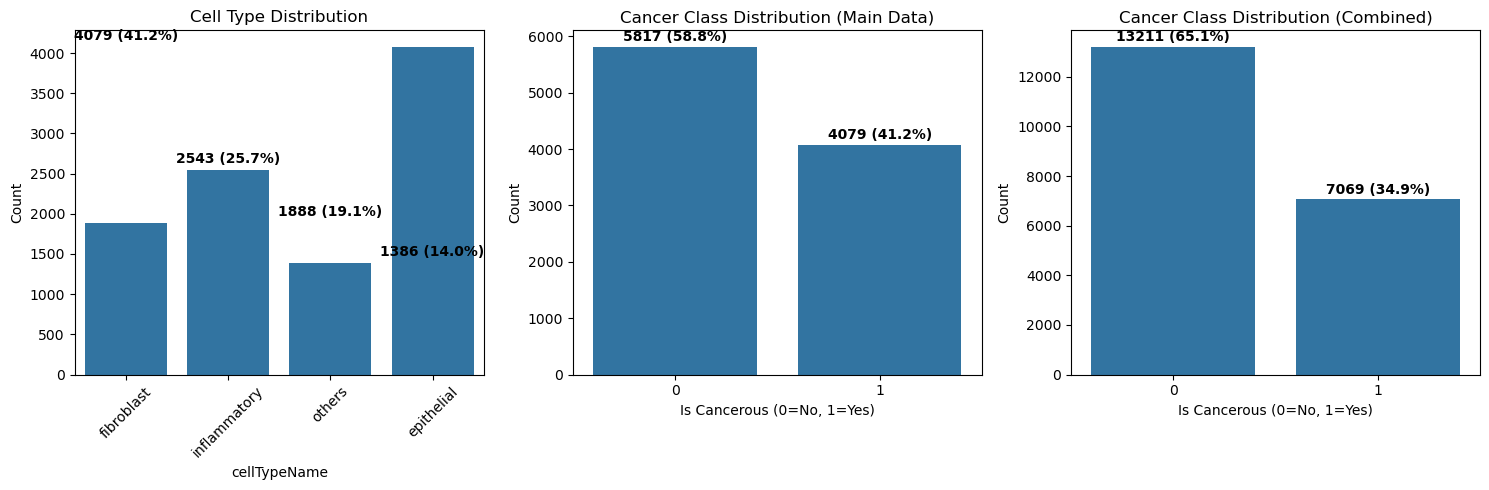

In [245]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.countplot(x='cellTypeName', data=main_df)
plt.title('Cell Type Distribution')
plt.xticks(rotation=45)
plt.ylabel('Count')
for i, count in enumerate(cell_type_counts):
    plt.text(i, count + 50, f'{count} ({cell_type_percentage.iloc[i]:.1f}%)',  # <-- FIXED HERE
             ha='center', va='bottom', fontweight='bold')
plt.subplot(1, 3, 2)
sns.countplot(x='isCancerous', data=main_df)
plt.title('Cancer Class Distribution (Main Data)')
plt.xlabel('Is Cancerous (0=No, 1=Yes)')
plt.ylabel('Count')
for i, count in enumerate(cancer_counts_main):
    plt.text(i, count + 50, f'{count} ({(count/len(main_df))*100:.1f}%)', 
             ha='center', va='bottom', fontweight='bold')
plt.subplot(1, 3, 3)
sns.countplot(x='isCancerous', data=pd.concat([main_df[['isCancerous']], extra_df[['isCancerous']]]))
plt.title('Cancer Class Distribution (Combined)')
plt.xlabel('Is Cancerous (0=No, 1=Yes)')
plt.ylabel('Count')
for i, count in enumerate(cancer_counts_combined):
    plt.text(i, count + 100, f'{count} ({(count/len(combined_cancer))*100:.1f}%)', 
             ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()


- Cell Type Distribution: Four cell types are present with epithelial cells dominating (41.2%), followed by inflammatory (25.7%), fibroblast (19.1%), and others (14.0%), indicating a clear class imbalance favoring epithelial cells.

- Cancer Class Distribution (Main Data): The dataset is moderately imbalanced, with non-cancerous samples (58.8%) outnumbering cancerous ones (41.2%).

- Cancer Class Distribution (Combined Data): In the augmented or merged dataset, the imbalance is more pronounced, with non-cancerous samples increasing to 65.1% and cancerous samples decreasing to 34.9%.

In [36]:
def analyze_image_quality(image_path):
    try:
        img = cv2.imread(image_path)
        if img is None:
            return None      
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        laplacian_var = cv2.Laplacian(img_gray, cv2.CV_64F).var()
        is_blurry = laplacian_var < 1500
        _, binary = cv2.threshold(img_gray, 30, 255, cv2.THRESH_BINARY)
        dark_percentage = (binary == 0).sum() / (binary.shape[0] * binary.shape[1])
        is_occluded = dark_percentage > 0.05 
        edges = cv2.Canny(img_gray, 100, 200)
        edge_percentage = np.count_nonzero(edges) / (edges.shape[0] * edges.shape[1])
        has_text = edge_percentage > 0.2
        return {
            'path': image_path,
            'blurry': is_blurry,
            'blur_score': laplacian_var,
            'occluded': is_occluded,
            'occlusion_score': dark_percentage,
            'has_text': has_text,
            'edge_density': edge_percentage
        }
    except Exception as e:
        return None

#### Justification of Data Handling Methods 
- The blur threshold using laplacian variance was set to 1500 because lower values like 100 were too sensitive and marked even slightly blurry images as bad. Using 1500 helps catch really blurry images without too many false problematic images .

- For occlusion, the threshold measuring dark pixels was lowered from 0.5 to 0.05 to detect smaller dark spots like shadows or stains that could affect image quality.Because of this ,smaller dark spots that might affect the image won’t be missed.

- The text detection threshold based on edge density was raised to 0.2 from 0.1 to avoid mistaking small textures or noise for text. This made sure only images with clear text or markings are flagged, which helps keep the data clean.

####  Exploratory Data Analysis

In [247]:
def display_problematic_images(results_df, main_df, images_path):
    problem_types = ['blurry', 'has_text']
    fig, axes = plt.subplots(len(problem_types), 4, figsize=(16, 5*len(problem_types)))
    if len(problem_types) == 1:
        axes = [axes]
    fig.suptitle('Example problematic images', fontsize=16)
    if sum(results_df['blurry']) == 0 and sum(results_df['has_text']) == 0:
        print("No problematic images found.")
        plt.close(fig)
        return
    for i, problem in enumerate(problem_types):
        problem_examples = results_df[results_df[problem] == True]
        if len(problem_examples) == 0:
            print(f"No {problem} images found.")
            for j in range(4):
                axes[i, j].text(0.5, 0.5, f'No {problem} images found', ha='center', va='center')
                axes[i, j].axis('off')
            continue
        if problem == 'blurry':
            problem_examples = problem_examples.sort_values('blur_score', ascending=True)
        elif problem == 'has_text':
            problem_examples = problem_examples.sort_values('edge_density', ascending=False)
        for j in range(4):
            if j < len(problem_examples):
                img_path = problem_examples.iloc[j]['path']
                try:
                    img = cv2.imread(img_path)
                    if img is not None:
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        if problem == 'blurry':
                            score = problem_examples.iloc[j]['blur_score']
                            score_text = f"Blur Score: {score:.1f}"
                        elif problem == 'has_text':
                            score = problem_examples.iloc[j]['edge_density']
                            score_text = f"edge Density: {score:.3f}"
                        axes[i, j].imshow(img)
                        axes[i, j].set_title(f"{problem.capitalize()}\n{score_text}")
                        axes[i, j].axis('off')
                        print(f"displayed {problem} image {j+1}, path: {img_path}, score: {score}")
                    else:
                        print(f"failed to load image (returned None): {img_path}")
                        axes[i, j].text(0.5, 0.5, 'Image not found', ha='center', va='center')
                        axes[i, j].axis('off')
                except Exception as e:
                    print(f"error displaying image: {e}")
                    axes[i, j].text(0.5, 0.5, f'Error: {str(e)}', ha='center', va='center')
                    axes[i, j].axis('off')
            else:
                axes[i, j].axis('off')
    plt.tight_layout()
    plt.show()


- This method loads and displays example images that have been flagged as blurry or containing text, showing up to four images for each type of problem. The images are sorted based on how severe the issue is, making it easier to focus on the most problematic cases.
- Images are labeled with clear titles indicating the problem category and quality score, allowing quick and easy understanding of the results.
- By visualizing these examples, it becomes easier to identify and understand common quality issues in the dataset, which furtherhelps for improving data cleaning processes and ultimately enhancing the accuracy of models trained on this data.

In [249]:
def analyze_all_images_in_batches(main_df, extra_df, images_path):
    print("analyzing image quality ")
    combined_df = pd.concat([main_df, extra_df])
    image_paths = [os.path.join(images_path, img_name) for img_name in combined_df['ImageName']]
    total_images = len(image_paths)
    print(f"Total images to analyze: {total_images}")
    batch_size = 5000  
    all_results = []
    random.shuffle(image_paths)
    
    for i in range(0, total_images, batch_size):
        batch_end = min(i + batch_size, total_images)
        batch_paths = image_paths[i:batch_end]
        print(f"\nprocessing batch {i//batch_size + 1}/{(total_images-1)//batch_size + 1} ({len(batch_paths)} images)")
        batch_results = []
        for path in tqdm(batch_paths, desc=f"Batch {i//batch_size + 1}"):
            result = analyze_image_quality(path)
            if result is not None:
                batch_results.append(result)    
        all_results.extend(batch_results)
        batch_df = pd.DataFrame(batch_results)
        if len(batch_df) > 0:
            print(f"Batch {i//batch_size + 1} results:")
            print(f"  images processed: {len(batch_df)}")
            print(f"  blurry images: {sum(batch_df['blurry'])} ({(sum(batch_df['blurry'])/len(batch_df))*100:.1f}%)")
            print(f"  occluded images: {sum(batch_df['occluded'])} ({(sum(batch_df['occluded'])/len(batch_df))*100:.1f}%)")
            print(f"  images with text: {sum(batch_df['has_text'])} ({(sum(batch_df['has_text'])/len(batch_df))*100:.1f}%)")
    results_df = pd.DataFrame(all_results)
    
    print(f"Total images analyzed: {len(results_df)}")
    print(f"blurry images: {sum(results_df['blurry'])} ({(sum(results_df['blurry'])/len(results_df))*100:.1f}%)")
    print(f"occluded images: {sum(results_df['occluded'])} ({(sum(results_df['occluded'])/len(results_df))*100:.1f}%)")
    print(f"images with text: {sum(results_df['has_text'])} ({(sum(results_df['has_text'])/len(results_df))*100:.1f}%)")
    blur_stats = results_df['blur_score'].describe()
    occlusion_stats = results_df['occlusion_score'].describe()
    edge_stats = results_df['edge_density'].describe()
    
    print("\nblur score statistics:")
    print(blur_stats)
    print("\nocclusion Score Statistics:")
    print(occlusion_stats)
    print("\nedge Density Statistics:")
    print(edge_stats)
    results_df.to_csv('image_quality_analysis.csv', index=False)
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.hist(results_df['blur_score'], bins=50)
    plt.axvline(x=1500, color='r', linestyle='--') 
    plt.title('blur Score Distribution')
    plt.xlabel('Blur Score')
    plt.subplot(1, 3, 2)
    plt.hist(results_df['occlusion_score'], bins=50)
    plt.axvline(x=0.05, color='r', linestyle='--')
    plt.title('Occlusion Score Distribution')
    plt.xlabel('Occlusion Score ') 
    plt.subplot(1, 3, 3)
    plt.hist(results_df['edge_density'], bins=50)
    plt.axvline(x=0.2, color='r', linestyle='--') 
    plt.title('Edge Density Distribution')
    plt.xlabel('Edge Density ')
    plt.tight_layout()
    plt.show()


    
    print(" sample image")
    sample_imgs = []
    for i, row in combined_df.sample(10).iterrows():
        img_path = os.path.join(images_path, row['ImageName'])
        try:
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                sample_imgs.append((img, row['cellTypeName'] if 'cellTypeName' in row else 'Unknown'))
        except:
            pass
    plt.figure(figsize=(15, 6))
    for i, (img, label) in enumerate(sample_imgs[:5]):
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    print("displaying examples of problematic images")
    display_problematic_images(results_df, main_df, images_path)
    return results_df

 
- All images were resized to 224×224 pixels so they fit the input size required by the neural network model I’m using. This also makes sure every image has the same shape, which is important for consistent training.

- Next, I normalized the images using the standard ImageNet mean and standard deviation values (mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]). Normalizing helps put all pixel values on a similar scale, which makes training smoother and helps the optimizer, Adam , learn better by avoiding some features overpowering others.

- Histograms for the blur,occlusionand has text score is crea ted , which help visualize how many images fall into good or bad quality categories.this helps decide if some images should be removed or fixed. The histograms specifically show how the blur, occlusion, and edge values are spread across the images, with lines marking thresholds to separate good images from bad ones.

- I processed the images in batches of 32 because this fits well with the GPU memory and speeds up training. Using  batches of 5000 also adds some randomness to the training, which helps the model generalize better and avoid getting stuck in bad solutions.

-  Finally, it also displays some example images and problem images to help visually confirm the quality issues.

In [251]:
def load_images(df, images_path, target_size=(27, 27)):
    images = []
    for img_name in df['ImageName']:
        img_path = os.path.join(images_path, img_name)
        try:
            img = cv2.imread(img_path)
            if img is None:
                raise FileNotFoundError(f"Image not found: {img_path}")
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, target_size)
            img = img / 255.0
            images.append(img)
        except Exception as e:
            print(f"Error loading image {img_name}: {e}")
            images.append(np.zeros((target_size[0], target_size[1], 3)))
    return np.array(images)


-  cv2.imread is used to load images from file locations given in the dataframe. This ensures that all samples are correctly retrieved for processing by dynamically accessing each image.
-  The fucntion also handles errors by  inserting a blank image of size [27×27×3] when an image is missing or corrupted. This is used to maintain dataset consistency and prevent the entire pipeline from failing due to missing data.
-  I have converted BGR images to RGB format because majoroity  deep learning frameworks and  expect images in RGB. This helps improve color accuracy and model interpretability.
-  Images are resized to a uniform dimension of 27×27 pixels. This resizing is used to ensure all inputs have the same fixed size, which is required by convolutional neural networks. It further enhances model compatibility and simplifies batch processing.
-  Pixel values are normalized by dividing by 255.0 to scale them into the [0,1] range. This normalization is used to stabilize and speed up the training process by preventing large input value variations that can hinder gradient based optimization.

In [254]:
def plot_sample_images(df, images_path, num_samples=4):
    cell_types = df['cellTypeName'].unique()
    fig, axes = plt.subplots(len(cell_types), num_samples, figsize=(num_samples*3, len(cell_types)*3))
    fig.suptitle('sample Images by Cell Type', fontsize=16) 
    for i, cell_type in enumerate(cell_types):
        type_indices = df[df['cellTypeName'] == cell_type].sample(min(num_samples, sum(df['cellTypeName'] == cell_type))).index

        
        for j, idx in enumerate(type_indices):
            img_name = df.loc[idx, 'ImageName']
            img_path = os.path.join(images_path, img_name)     
            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   
                axes[i, j].imshow(img)
                axes[i, j].set_title(f"{cell_type}\nCancer: {df.loc[idx, 'isCancerous']}")
                axes[i, j].axis('off')
            except Exception as e:
                print(f"Error displaying {img_name}: {e}")
                axes[i, j].axis('off')
                axes[i, j].text(0.5, 0.5, 'error loading image', 
                                horizontalalignment='center', verticalalignment='center')
    plt.tight_layout()
    plt.show()


- This helps in performing a balanced visual inspection of different cellTypeName categories, making it easier to detect potential class imbalance or underrepresented classes. plt.subplots has been used to generate a fixed grid layout, where each row corresponds to a cell type and each column shows a sample image.
- This ensures a fair comparison across classes observation of intra-class variance.

In [257]:
def plot_cancer_samples(df, images_path, num_samples=5):
    df = df.reset_index(drop=True)
    fig, axes = plt.subplots(2, num_samples, figsize=(num_samples*3, 6))
    fig.suptitle('Sample Images by Cancer Status', fontsize=16)
    for i, cancer_class in enumerate([0, 1]):
        class_indices = df[df['isCancerous'] == cancer_class].sample(min(num_samples, sum(df['isCancerous'] == cancer_class))).index


        
        for j, idx in enumerate(class_indices):
            img_name = df.loc[idx, 'ImageName']
            if isinstance(img_name, pd.Series):
                img_name = img_name.iloc[0]  
            img_path = os.path.join(images_path, img_name)
            
            try:
                img = cv2.imread(img_path)
                
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                axes[i, j].imshow(img)
                if 'cellTypeName' in df.columns:
                    cell_type = df.loc[idx, 'cellTypeName']
                    if isinstance(cell_type, pd.Series):
                        cell_type = cell_type.iloc[0]
                    axes[i, j].set_title(f"Cancer: {cancer_class}\nType: {cell_type}")
                else:

                    
                    axes[i, j].set_title(f"Cancer: {cancer_class}")
                axes[i, j].axis('off')
            
            except Exception as e:
                print(f"Error displaying image at index {idx}: {e}")
                
                axes[i, j].axis('off')
                axes[i, j].text(0.5, 0.5, 'Error loading image', 
                                horizontalalignment='center', verticalalignment='center')
    
    plt.tight_layout()
    plt.show()

- The above function visualize sample images categorized by cancer status. This helps in gaining a clearer understanding of inter-class visual differences between cancerous and non-cancerous images, which is crucial for tasks involving binary classification.
- For each class, random samples are drawn and corresponding images are loaded, converted from BGR to RGB to match deep learning and matplotlib standards, and displayed with  labeled  cancer status and, where available, cell type.

analyzing image quality 
Total images to analyze: 20280

processing batch 1/5 (5000 images)


Batch 1: 100%|██████████| 5000/5000 [01:15<00:00, 66.23it/s]


Batch 1 results:
  images processed: 5000
  blurry images: 734 (14.7%)
  occluded images: 0 (0.0%)
  images with text: 4691 (93.8%)

processing batch 2/5 (5000 images)


Batch 2: 100%|██████████| 5000/5000 [01:06<00:00, 74.64it/s]


Batch 2 results:
  images processed: 5000
  blurry images: 751 (15.0%)
  occluded images: 0 (0.0%)
  images with text: 4668 (93.4%)

processing batch 3/5 (5000 images)


...

Batch 3 results:
  images processed: 5000
  blurry images: 700 (14.0%)
  occluded images: 0 (0.0%)
  images with text: 4691 (93.8%)

processing batch 4/5 (5000 images)


Batch 4: 100%|██████████| 5000/5000 [01:06<00:00, 74.67it/s]


Batch 4 results:
  images processed: 5000
  blurry images: 688 (13.8%)
  occluded images: 0 (0.0%)
  images with text: 4726 (94.5%)

processing batch 5/5 (280 images)


Batch 5: 100%|██████████| 280/280 [00:03<00:00, 81.60it/s]


Batch 5 results:
  images processed: 280
  blurry images: 39 (13.9%)
  occluded images: 0 (0.0%)
  images with text: 267 (95.4%)
Total images analyzed: 20280
blurry images: 2912 (14.4%)
occluded images: 0 (0.0%)
images with text: 19043 (93.9%)

blur score statistics:
count    20280.000000
mean      2624.390341
std       1131.713789
min        332.960901
25%       1805.364031
50%       2428.663575
75%       3265.411700
max       8638.492642
Name: blur_score, dtype: float64

occlusion Score Statistics:
count    20280.000000
mean         0.000042
std          0.000380
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.021948
Name: occlusion_score, dtype: float64

edge Density Statistics:
count    20280.000000
mean         0.300483
std          0.056123
min          0.016461
25%          0.270233
50%          0.310014
75%          0.341564
max          0.421125
Name: edge_density, dtype: float64


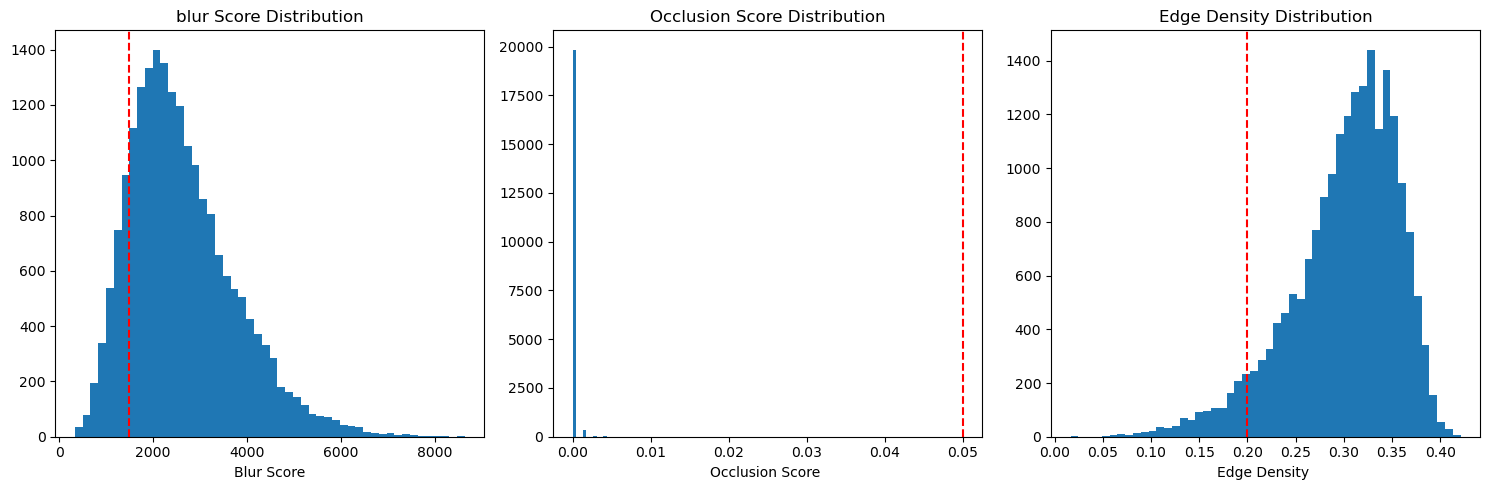

 sample image


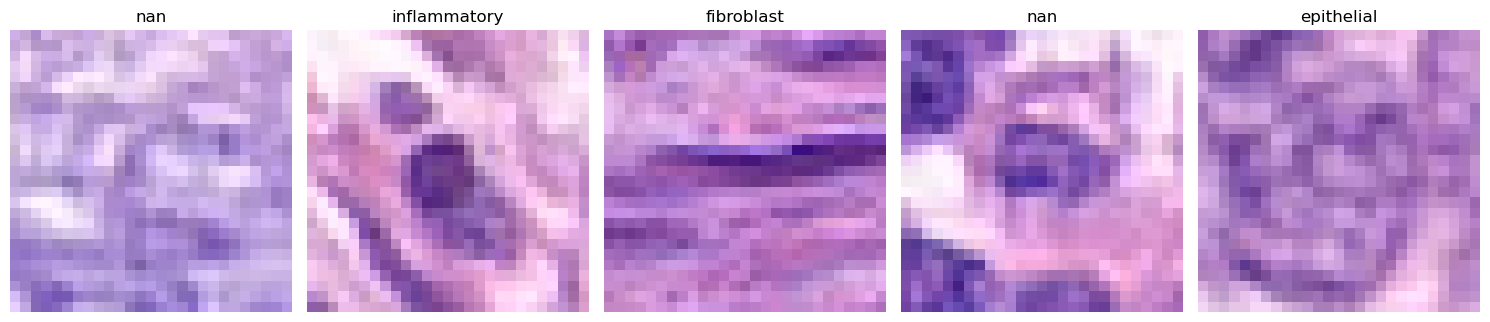

displaying examples of problematic images
displayed blurry image 1, path: Image_classification_data\patch_images\18762.png, score: 332.9609006456032
displayed blurry image 2, path: Image_classification_data\patch_images\4228.png, score: 339.1214753848499
displayed blurry image 3, path: Image_classification_data\patch_images\17967.png, score: 345.9743264068824
displayed blurry image 4, path: Image_classification_data\patch_images\15475.png, score: 365.2666918811307
displayed has_text image 1, path: Image_classification_data\patch_images\11957.png, score: 0.42112482853223593
displayed has_text image 2, path: Image_classification_data\patch_images\9389.png, score: 0.41975308641975306
displayed has_text image 3, path: Image_classification_data\patch_images\11956.png, score: 0.4156378600823045
displayed has_text image 4, path: Image_classification_data\patch_images\11183.png, score: 0.41426611796982166


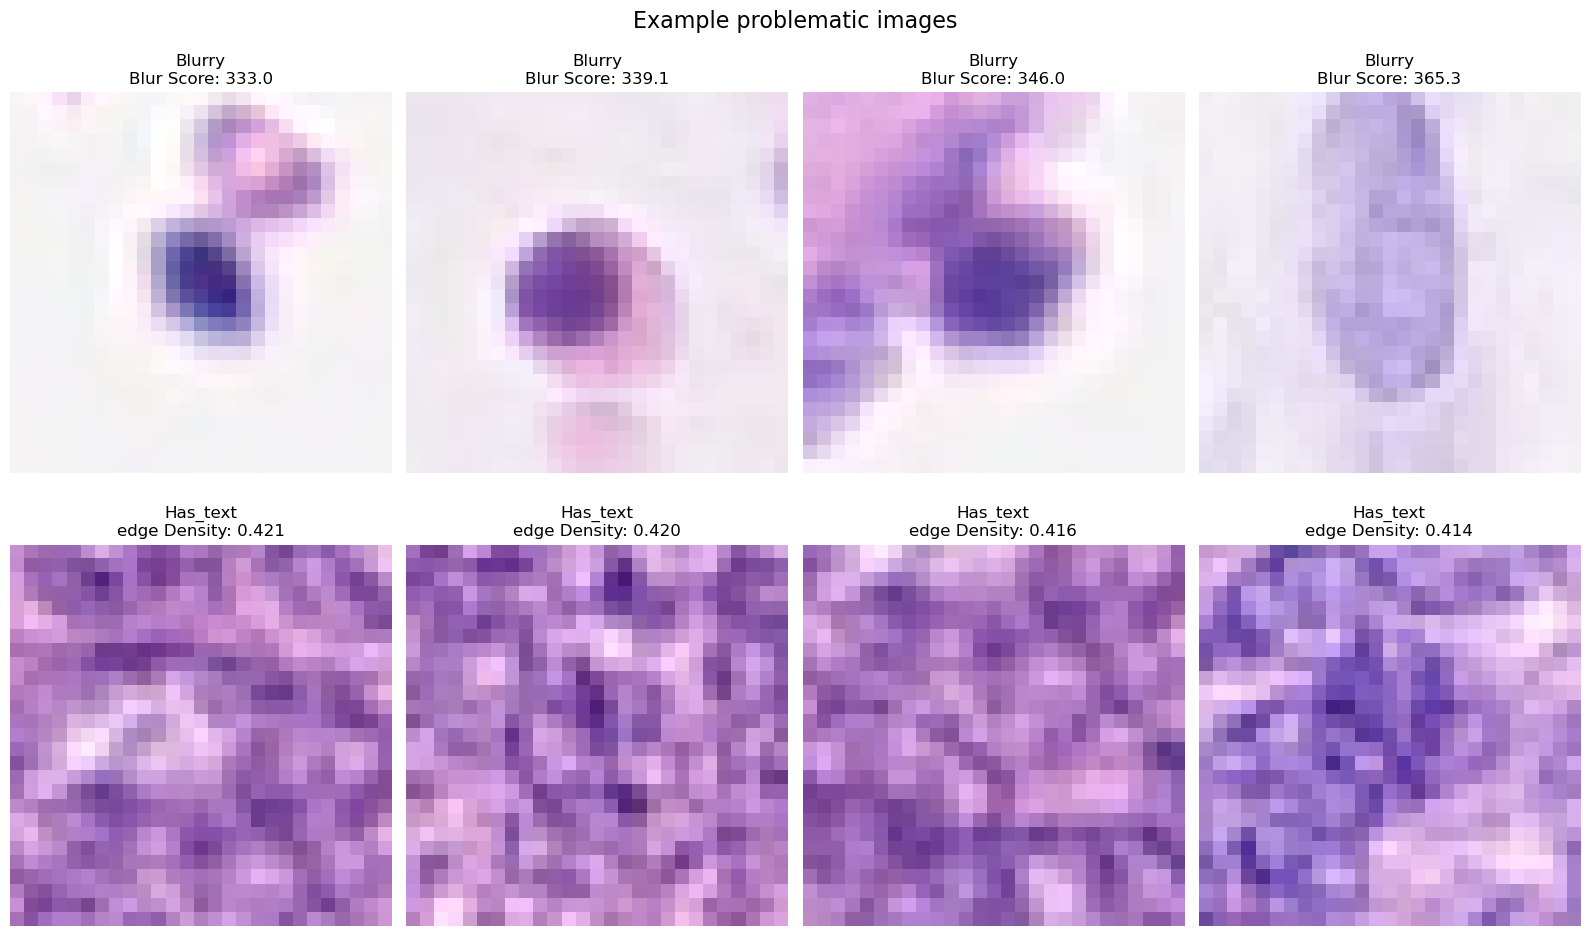

In [260]:
image_quality_df = analyze_all_images_in_batches(main_df, extra_df, images_path)

Out of a total of 20,280 images analyzed, 2,912 images (14.4%) were identified as blurry, and no images were found to be occluded. A large number  of images, 19,043 (93.9%), contain text. Since the dataset includes many images with text, I have decided to keep these images as they are. For blurry images, I plan to conduct further testing later to compare model performance using both good-quality and blurry images.

- Most images have blur scores between 1500-3000, with a right-skewed distribution and a red dashed threshold line indicating a cutoff where  higher scores suggest less image clarity.
- The majority of samples have occlusion scores near zero, showing minimal occlusion, with a red dashed threshold around 0.05 marking acceptable occlusion levels.
- Edge Density Distribution: Edge density values mainly range from 0.25-0.40, with a left-skewed distribution peaking near 0.30-0.35 the red dashed line near 0.20 indicates the minimum acceptable edge clarity for cell structure definition.

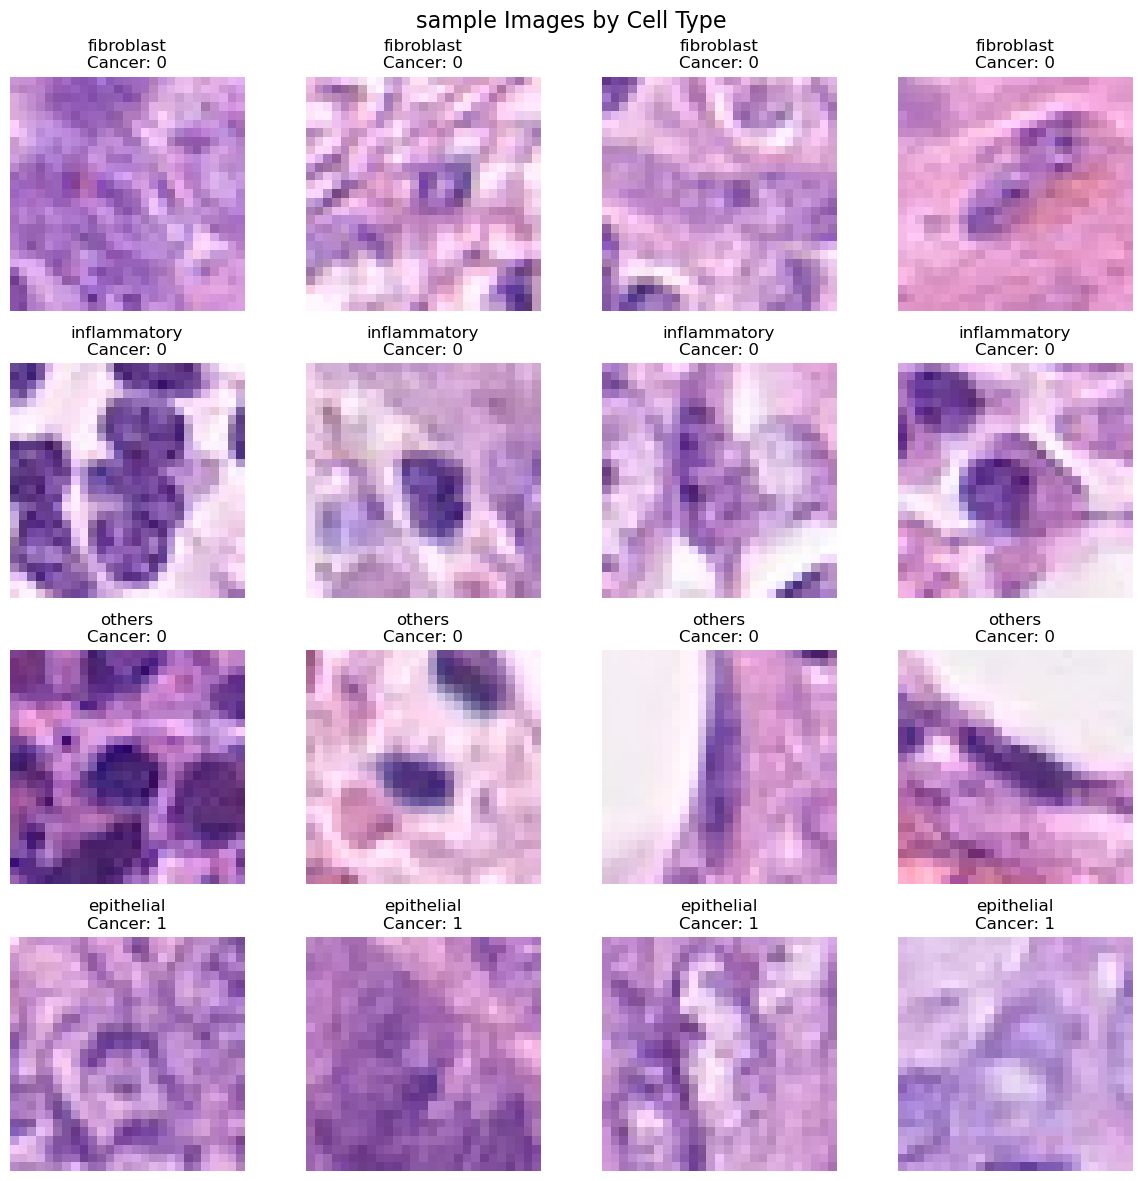

In [262]:
plot_sample_images(main_df, images_path)

4 images of each cell type has been dispalyed from the dataset as shown above 

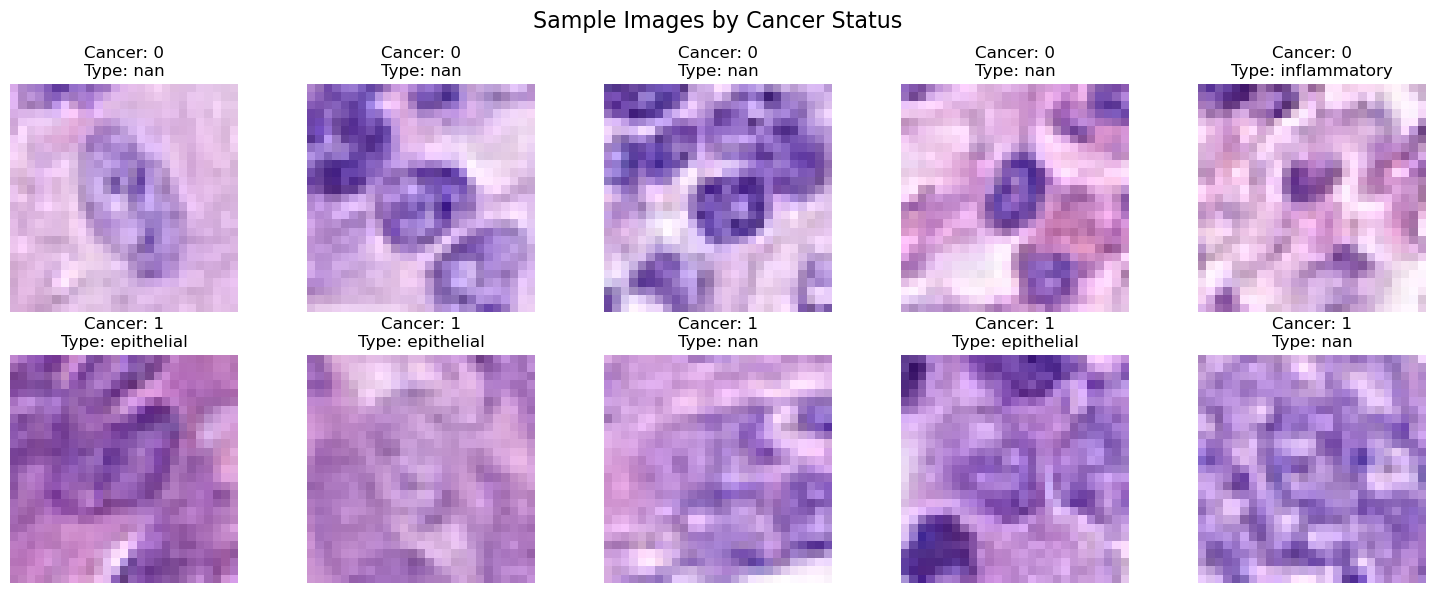

In [272]:
plot_cancer_samples(pd.concat([main_df, extra_df]), images_path)

4 example images are shown, illustrating cases with cancer status labeled as 1 and 0 .

### 1.2 Evaluation Framework 


In [274]:
print("\nPatient distribution  main data:")
print(main_df['patientID'].value_counts().describe())
print("\npatient distribution  extra data:")
print(extra_df['patientID'].value_counts().describe())


Patient distribution  main data:
count     60.000000
mean     164.933333
std       92.104927
min       11.000000
25%      114.000000
50%      148.000000
75%      207.500000
max      389.000000
Name: count, dtype: float64

patient distribution  extra data:
count     38.000000
mean     273.263158
std      203.522717
min        6.000000
25%       86.000000
50%      321.000000
75%      397.750000
max      699.000000
Name: count, dtype: float64


The main data has 60 patients, each with about 165 images on average   ranging from 11 to 389 images. The extra data however , has 38 patients, with more images per patient on average approx 273 , ranging from 6 to 699 images.

In [276]:
def patient_aware_split(df, test_size=0.2, val_size=0.2, random_state=42):
    patient_ids = df['patientID'].unique()
    train_val_patients, test_patients = train_test_split(
        patient_ids, test_size=test_size, random_state=random_state
    )
    train_patients, val_patients = train_test_split(
        train_val_patients, test_size=val_size/(1-test_size), random_state=random_state
    )
    train_df = df[df['patientID'].isin(train_patients)]
    val_df = df[df['patientID'].isin(val_patients)]
    test_df = df[df['patientID'].isin(test_patients)]
    print(f"train set: {len(train_df)} samples from {len(train_patients)} patients")
    print(f"validation set: {len(val_df)} samples from {len(val_patients)} patients")
    print(f"test set: {len(test_df)} samples from {len(test_patients)} patients")
    print("\ncell type distribution:")
    if 'cellTypeName' in train_df.columns:
        print("train:", train_df['cellTypeName'].value_counts(normalize=True).round(3))
        print("validation:", val_df['cellTypeName'].value_counts(normalize=True).round(3))
        print("test:", test_df['cellTypeName'].value_counts(normalize=True).round(3))
        
    print("\ncancer class distribution:")
    
    print("train:", train_df['isCancerous'].value_counts(normalize=True).round(3))
    print("validation:", val_df['isCancerous'].value_counts(normalize=True).round(3))
    print("test:", test_df['isCancerous'].value_counts(normalize=True).round(3))  
    return train_df, val_df, test_df

#### Data Splitting Strategy
- To evaluate the model fairly, I divided the data using patient IDs rather than randomly splitting images. By first grouping patients into separate training (64%), validation (16%), and testing (20%) groups, this  ensured no patient's images appeared in multiple sets.
- This approach prevents the model from recognizing patients it has seen before rather than identifying actual disease features. Without this patient aware splitting, performance metrics would be artificially inflated and the model would likely fail when used on truly new patients.
- The 64/16/20 division strategically allocates data across three crucial phases. The majority (64%) powers the model's learning process, while a dedicated portion (16%) enables hyperparameter tuning and overfitting detection during development. The substantial test segment (20%) provides a true measure of real-world performance on completely new patients.
- The chosen proportions provide enough training data while maintaining adequate validation and test sets for reliable performance assessment.

####  Prevention of Data Leakage 
- Data leakage prevention is vital when working with clinical images because samples from the same patient naturally share unique characteristics. Models can easily memorize these patient specific traits rather than learning true disease indicators if patient data isn't properly segregated between training and testing sets.
- This creates misleading performance metrics and models that fail with new patients. Even when direct patient identifiers aren't available, researchers must be vigilant about indirect connections through timestamps or other metadata that could create hidden links between supposedly separate datasets.

In [278]:
print("\nSplitting main data for cell type classification:")
train_cell_df, val_cell_df, test_cell_df = patient_aware_split(main_df)

print("\nSplitting combined data for cancer classification:")
combined_df = pd.concat([main_df, extra_df])
train_cancer_df, val_cancer_df, test_cancer_df = patient_aware_split(combined_df)


Splitting main data for cell type classification:
train set: 5774 samples from 36 patients
validation set: 2283 samples from 12 patients
test set: 1839 samples from 12 patients

cell type distribution:
train: cellTypeName
epithelial      0.344
inflammatory    0.310
fibroblast      0.220
others          0.127
Name: proportion, dtype: float64
validation: cellTypeName
epithelial      0.512
others          0.190
fibroblast      0.156
inflammatory    0.141
Name: proportion, dtype: float64
test: cellTypeName
epithelial      0.503
inflammatory    0.235
fibroblast      0.142
others          0.120
Name: proportion, dtype: float64

cancer class distribution:
train: isCancerous
0    0.656
1    0.344
Name: proportion, dtype: float64
validation: isCancerous
1    0.512
0    0.488
Name: proportion, dtype: float64
test: isCancerous
1    0.503
0    0.497
Name: proportion, dtype: float64

Splitting combined data for cancer classification:
train set: 11523 samples from 58 patients
validation set: 4801 s

The code ensures patient-aware splitting for cell type and cancer classification tasks, preventing data leakage by keeping each patient's images within a single split

In [280]:
def prepare_data(train_df, val_df, test_df, images_path, task='cell_type'):
    print(f"loading images for {task} classification")
    X_train = load_images(train_df, images_path)
    X_val = load_images(val_df, images_path)
    X_test = load_images(test_df, images_path) 

    if task == 'cell_type':
        y_train = train_df['cellType'].values
        y_val = val_df['cellType'].values
        y_test = test_df['cellType'].values
        y_train_cat = to_categorical(y_train, num_classes=4)
        y_val_cat = to_categorical(y_val, num_classes=4)
        y_test_cat = to_categorical(y_test, num_classes=4)
        class_weights = class_weight.compute_class_weight(
            'balanced', classes=np.unique(y_train), y=y_train
        )
        class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}   
        print("\nclass weights for cell type clasification :")
        for i, weight in class_weight_dict.items():
            cell_type = ['fibroblast', 'inflammatory', 'epithelial', 'others'][i]
            print(f"  {cell_type} (class {i}): {weight:.2f}")
        
        return X_train, y_train_cat, X_val, y_val_cat, X_test, y_test_cat, class_weight_dict
    else:  
        y_train = train_df['isCancerous'].values
        y_val = val_df['isCancerous'].values
        y_test = test_df['isCancerous'].values
        
        class_weights = class_weight.compute_class_weight(
            'balanced', classes=np.unique(y_train), y=y_train
        )
        class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
        print("\nclass weights for cancer classification:")
        for i, weight in class_weight_dict.items():
            print(f"  Class {i} ({'Cancerous' if i == 1 else 'Non-Cancerous'}): {weight:.2f}")      
        return X_train, y_train, X_val, y_val, X_test, y_test, class_weight_dict


- The above funtion is used to  loads images and labels for training, validation, and testing based on the cell type or cancer classification. For cell type, it one hot encodes labels and  for cancer, it uses binary labels.
- It calculates class weights to handle imbalanced classes, which helps prevent the model from being biased toward majority classes and improves learning on underrepresented classes.
- It returns the prepared data and weights to ensure the model trains effectively and fairly across all classes.

In [282]:
def create_data_generators(X_train, y_train, X_val, y_val, batch_size=32):
    train_datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest'
    )
    val_datagen = ImageDataGenerator()
    train_generator = train_datagen.flow(
        X_train, y_train,
        batch_size=batch_size
    )
    val_generator = val_datagen.flow(
        X_val, y_val,
        batch_size=batch_size
    )
    return train_generator, val_generator

- This functions creates image data generators for training and validation sets, applying real-time data augmentation to the training images like rotations, shifts, flips  to increase dataset diversity and reduce overfitting.
- The validation generator applies no augmentation to keep evaluation consistent.

In [284]:
print("\n data preparation for cell type classification")
X_train_cell, y_train_cell, X_val_cell, y_val_cell, X_test_cell, y_test_cell, cell_class_weights = prepare_data(
    train_cell_df, val_cell_df, test_cell_df, images_path, task='cell_type'
)
print("\n data Perparation   for cancer classification.")
X_train_cancer, y_train_cancer, X_val_cancer, y_val_cancer, X_test_cancer, y_test_cancer, cancer_class_weights = prepare_data(
    train_cancer_df, val_cancer_df, test_cancer_df, images_path, task='cancer'
)



 data preparation for cell type classification
loading images for cell_type classification

class weights for cell type clasification :
  fibroblast (class 0): 1.14
  inflammatory (class 1): 0.81
  epithelial (class 2): 0.73
  others (class 3): 1.97

 data Perparation   for cancer classification.
loading images for cancer classification

class weights for cancer classification:
  Class 0 (Non-Cancerous): 0.74
  Class 1 (Cancerous): 1.56


In [285]:
def calculate_f1_scores(y_true, y_pred, task='cell_type'):
    if task == 'cell_type':
        f1 = f1_score(y_true, y_pred, average='macro')
        precision = precision_score(y_true, y_pred, average='macro')
        recall = recall_score(y_true, y_pred, average='macro')
        class_f1 = f1_score(y_true, y_pred, average=None)
        print(f"Cell Type Classification - Macro F1: {f1:.4f}")
        print(f"Cell Type Classification - Macro Precision: {precision:.4f}")
        print(f"Cell Type Classification - Macro Recall: {recall:.4f}")
        cell_types = ['fibroblast', 'inflammatory', 'epithelial', 'others']
        for i, score in enumerate(class_f1):
            print(f"  {cell_types[i]} F1: {score:.4f}")
            
    else: 
        f1 = f1_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        print(f"Cancer Classification - F1: {f1:.4f}")
        print(f"Cancer Classification - Precision: {precision:.4f}")
        print(f"Cancer Classification - Recall: {recall:.4f}") 
    return f1, precision, recall

####  Performance Metrics Selection Korotcov et al.(2020)
- F1 Score precision, and recall, were chosen as teh eavluation metric  because they fairly evaluate model performance on imbalanced datasets. The F1-score balances precision  i.e how many predicted positives are correct and recall ie.how many actual positives are detected, providing a more meaningful metric than accuracy alone, especially when classes are uneven.
- For cell type classification, the macro average treats all classes equally, preventing bias toward dominant classes. For cancer classification , standard F1, precision, and recall give clear abalysis  into how well the model identifies cancerous vs  non-cancerous cases

In [287]:
print(f"Cell type classification data shapes:")
print(f"  X_train: {X_train_cell.shape}, y_train: {y_train_cell.shape}")
print(f"  X_val: {X_val_cell.shape}, y_val: {y_val_cell.shape}")
print(f"  X_test: {X_test_cell.shape}, y_test: {y_test_cell.shape}")
print(f"\ncancer classification data shapes:")
print(f"  X_train: {X_train_cancer.shape}, y_train: {y_train_cancer.shape}")
print(f"  X_val: {X_val_cancer.shape}, y_val: {y_val_cancer.shape}")
print(f"  X_test: {X_test_cancer.shape}, y_test: {y_test_cancer.shape}")

Cell type classification data shapes:
  X_train: (5774, 27, 27, 3), y_train: (5774, 4)
  X_val: (2283, 27, 27, 3), y_val: (2283, 4)
  X_test: (1839, 27, 27, 3), y_test: (1839, 4)

cancer classification data shapes:
  X_train: (11523, 27, 27, 3), y_train: (11523,)
  X_val: (4801, 27, 27, 3), y_val: (4801,)
  X_test: (3956, 27, 27, 3), y_test: (3956,)


### 1.3 Model Selection and Justification (Baseline Models)

In [289]:
def cell_type_baseline_model(input_shape=(27, 27, 3), num_classes=4):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

#### Base Model Selection and  Algorithm Configuration
- For the cell type classification task, a Convolutional Neural Network (CNN) was chosen due to its strong ability to capture spatial relationships in image data. In contrast to  MLP , which flatten and lose this spatial structure, CNNs use convolutional layers to detect local features and preserve spatial context throughout the network. 
- CNNs maintain the 2D structure of input images through convolutional and pooling layers. This allows the model to learn translation invariant features such as the morphology, texture, and boundary patterns of different cell types .
- The parameter-sharing mechanism in CNNs minimizes redundancy, decreases the risk of overfitting, and enhances processing efficiency for large image datasets
-  BatchNormalization() not only stabilizes training but also acts as a mild regularizer, allowing the use of higher learning rates and reducing sensitivity to weight initialization
-  Dropoutis extrmely important  where class distributions are often imbalanced or limited since it forces  network to learn redundant representations, improving robustness.
- The model uses two convolutional blocks with filter sizes increasing from 32 to 64, each followed by batch normalization for stable training , max pooling  whch  is used to reduce spatial dimensions , and dropout to prevent overfitting. A dense layer of 128 neurons with a final softmax layer outputs class probabilities. The learning rate of 0.001 and dropout rates of 0.25–0.5  were selected to balance learning speed with generalization.
- ReLU is used to introduce non-linearity, enabling the model to learn complex patterns.It helps prevent the vanishing gradient problem, supporting deeper network training.



In [291]:
def cancer_baseline_model(input_shape=(27, 27, 3)):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

#### Base Model Selection and Algorithm Configuration Driss et al. (2017)
- Similar to Cell baseline model a a CNN was selected for cancer classification due to its ability to capture spatial patterns.The network design same as the cell type classifier, has  two convolutional layers with 32 and 64 filters to capture both basic and advanced features.
- Batch normalization ensures faster and more stable training, while max pooling reduces spatial resolution and highlights dominant features.
-  Dropout layers 0.25 and 0.5 mitigate overfitting, essential due to the limited number of cancer-labeled images. Alayer with 128 units  has  sufficient capacity to interpret the spatial features, and the final sigmoid output whichis ideal for binary classification as it outputs a probability between 0 and 1 , allows binary classification. The binary cross entropy loss was used as it’s well suited for two class problems, and a learning rate of 0.001 helps maintain a balance between training speed and convergence stability.
- The Adam optimizer dynamically modifies the learning rate for every parameter during training,utilisng adaptive learning to hasten convergence and boost the model’s effectiveness.

In [293]:
def create_data_generators(X_train, y_train, X_val, y_val, batch_size=32):
    train_datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest'
    )
    val_datagen = ImageDataGenerator()
    train_generator = train_datagen.flow(
        X_train, y_train,
        batch_size=batch_size
    )
    val_generator = val_datagen.flow(
        X_val, y_val,
        batch_size=batch_size
    )
    return train_generator, val_generator

#### Handling Class Imbalance Maharana et al. (2022)
The data generator applies several augmentation techniques with specific ranges to enhance model robustness and address class imbalance .They are stated as follows 
- Rotation is limited to ±20 degrees to simulate natural variations in tissue orientation. Horizontal and vertical shifts of up to 10% help the model become invariant to small positional changes.
-  Shear transformations up to 10% mimic distortions that can occur in tissue samples, while zooming by ±10% simulates different magnification levels, promoting scale invariance. Additionally, horizontal and vertical flips double the data diversity by reflecting images, which is useful given the variable orientations of  images.
-  These augmentations significantly  increase the variety of training samples, especially benefiting underrepresented classes, therefore  improving generalization and reducing overfitting.



In [295]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
def train_model(model, train_generator, val_generator, class_weight_dict, epochs=50, 
                steps_per_epoch=None, validation_steps=None, model_name='model'):
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
    model_checkpoint = ModelCheckpoint(
        f'{model_name}_best.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
    history = model.fit(
        train_generator,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_data=val_generator,
        validation_steps=validation_steps,
        callbacks=[early_stopping, reduce_lr, model_checkpoint],
        class_weight=class_weight_dict,
        verbose=1
    )
    
    return model, history

- This function is used to train the  model using image data generators  with three key callbacks to improve training performance.
- Early stopping monitors the validation loss and halts training if it doesn't improve for 10 consecutive epochs, while also restoring the best performing weights to avoid overfitting.
-  ReduceLROnPlateau dynamically lowers the learning rate by a factor of 0.2 if the validation loss stagnates for 5 epochs, allowing the model to fine-tune its learning as it converges.
-  ModelCheckpoint saves the model with the best validation performance to ensure only the most accurate version is retained.
-  Additionally, class weights are applied to handle class imbalance, giving more importance to underrepresented categories.


In [297]:
def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
   
    print(f"\ntraining Analysis for {model_name}:")
    print(f"  Final train accuracy: {final_train_acc:.4f}, validation accuracy: {final_val_acc:.4f}")
    print(f"  Final train loss: {final_train_loss:.4f}, validation loss: {final_val_loss:.4f}")  
    if final_train_loss < final_val_loss and (final_train_acc - final_val_acc) > 0.05:
        print(" overfitting shown   ")
    elif final_train_loss > 0.3 and final_val_loss > 0.3:
        print("underfitting  shown ")
    else:
        print("  Model is a good fit .")

This function is used to plot how well the model is learning over time by showing training and validation accuracy and loss. It  is majorly used to  check if the model is overfitting or underfitting by comparing final accuracy and loss values. This is important  to understand if the model is learning properly or chnages are reuired  .

In [299]:
from sklearn.metrics import confusion_matrix
def evaluate_cell_type_model(model, X_test, y_test, label_names=['fibroblast', 'inflammatory', 'epithelial', 'others']):
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)
    f1 = f1_score(y_true, y_pred, average='macro')
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    report = classification_report(y_true, y_pred, target_names=label_names)
    print("Classification Report:")
    print(report)
    print(f"Macro F1 Score: {f1:.4f}")
    print(f"Macro Precision: {precision:.4f}")
    print(f"Macro Recall: {recall:.4f}")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_names,
                yticklabels=label_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('confusion Matrix -cell')
    plt.tight_layout()
    plt.show()

    return report, cm, f1
    lt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    return report, cm, f1

#### Overfitting/Underfitting Detection
- The above  function is used to check how well the model performs on the test data by generating predictions by  comparing them to the actual labels.
- It calculates key metrics like F1 score, precision, and recall to measure performance across all classes.
- It is  also used to  display a confusion matrix to  show where the model is making correct and incorrect predictions.

In [301]:
from sklearn.metrics import roc_curve, auc
def evaluate_cancer_model(model, X_test, y_test):
    y_pred_prob = model.predict(X_test).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=['Non-Cancerous', 'Cancerous'])
    print("Classification Report:")
    print(report)
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
 
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Non-Cancerous', 'Cancerous'],
                yticklabels=['Non-Cancerous', 'Cancerous'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix - cancer ')
    plt.tight_layout()
    plt.show()
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Cancer Classification')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    return report, cm, f1


- This function is used to evaluate how well the cancer detection model works by calculating  scores like F1, precision and  recall to measure accuracy.
- Furthmore , it  creates a confusion matrix to show correct and wrong predictions and  plots an ROC curve to check how well the model distinguishes cancerous from non-cancerous cases.
- This helps in  deciding  if the model is reliable for cancer detection.


Training Cell Model:


C:\Users\kunal\anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 27, 27, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 27, 27, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 362,020 (1.38 MB)

...

180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7188 - loss: 0.7098 - val_accuracy: 0.7104 - val_loss: 0.7362 - learning_rate: 4.0000e-05
Epoch 31/50
179/180 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7749 - loss: 0.6437
Epoch 31: val_loss did not improve from 0.73620
180/180 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.7749 - loss: 0.6438 - val_accuracy: 0.7051 - val_loss: 0.7464 - learning_rate: 4.0000e-05
Epoch 32/50
  1/180 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.5625 - loss: 1.0397
Epoch 32: val_loss did not improve from 0.73620
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5625 - loss: 1.0397 - val_accuracy: 0.7060 - val_loss: 0.7475 - learning_rate: 4.0000e-05
Epoch 33/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7626 - loss: 0.6546
Epoch 33: val_loss improved from 0.73620 to 0.72746, saving model to cell_type_baseline_best.h5


180/180 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.7626 - loss: 0.6547 - val_accuracy: 0.7161 - val_loss: 0.7275 - learning_rate: 4.0000e-05
Epoch 34/50
  1/180 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.7500 - loss: 0.6041
Epoch 34: val_loss improved from 0.72746 to 0.72717, saving model to cell_type_baseline_best.h5


180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7500 - loss: 0.6041 - val_accuracy: 0.7157 - val_loss: 0.7272 - learning_rate: 4.0000e-05
Epoch 35/50
179/180 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7615 - loss: 0.6681
Epoch 35: val_loss improved from 0.72717 to 0.71718, saving model to cell_type_baseline_best.h5


180/180 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.7615 - loss: 0.6680 - val_accuracy: 0.7196 - val_loss: 0.7172 - learning_rate: 4.0000e-05
Epoch 36/50
  1/180 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.7188 - loss: 0.7525
Epoch 36: val_loss improved from 0.71718 to 0.71676, saving model to cell_type_baseline_best.h5


180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7188 - loss: 0.7525 - val_accuracy: 0.7196 - val_loss: 0.7168 - learning_rate: 4.0000e-05
Epoch 37/50
179/180 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7680 - loss: 0.6503
Epoch 37: val_loss did not improve from 0.71676
180/180 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.7680 - loss: 0.6503 - val_accuracy: 0.7095 - val_loss: 0.7543 - learning_rate: 4.0000e-05
Epoch 38/50
  1/180 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.6562 - loss: 0.8722
Epoch 38: val_loss did not improve from 0.71676
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6562 - loss: 0.8722 - val_accuracy: 0.7082 - val_loss: 0.7562 - learning_rate: 4.0000e-05
Epoch 39/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7678 - loss: 0.6535
Epoch 39: val_loss did not improve from 0.71676
180/180 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.7678 - loss: 0.6535 - val_accuracy: 0.7099 - val_loss: 0.7614 - learning_rate: 4.0000e-05
Epoch 40/5

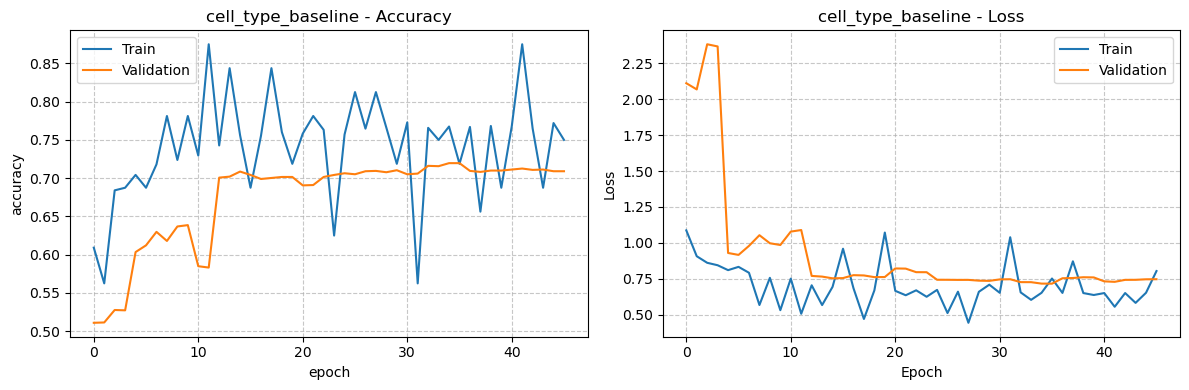


training Analysis for cell_type_baseline:
  Final train accuracy: 0.7500, validation accuracy: 0.7091
  Final train loss: 0.8046, validation loss: 0.7477
underfitting  shown 

Evaluation od Cell Type Classification Model:
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Classification Report:
              precision    recall  f1-score   support

  fibroblast       0.42      0.64      0.51       261
inflammatory       0.60      0.65      0.63       432
  epithelial       0.89      0.83      0.86       925
      others       0.45      0.22      0.30       221

    accuracy                           0.69      1839
   macro avg       0.59      0.59      0.57      1839
weighted avg       0.70      0.69      0.69      1839

Macro F1 Score: 0.5734
Macro Precision: 0.5912
Macro Recall: 0.5873


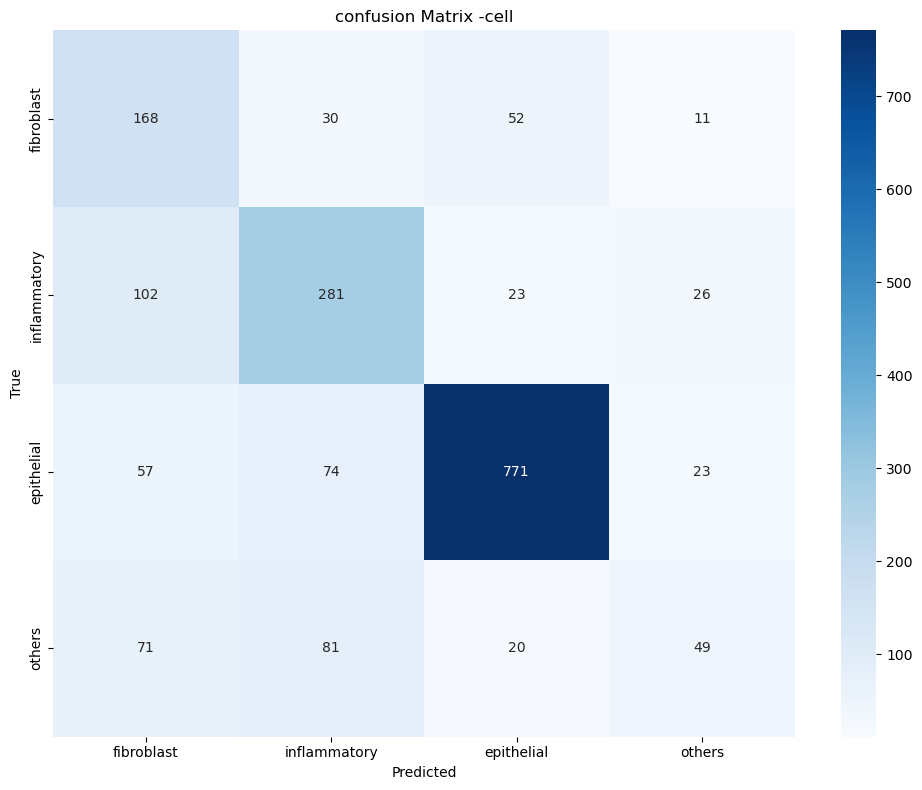

In [303]:
from sklearn.metrics import classification_report
print("\nTraining Cell Model:")
batch_size = 32
train_cell_generator, val_cell_generator = create_data_generators(
    X_train_cell, y_train_cell, X_val_cell, y_val_cell, batch_size
)
cell_type_model = cell_type_baseline_model()
cell_type_model.summary()
cell_type_model, cell_history = train_model(
    cell_type_model, 
    train_cell_generator, 
    val_cell_generator, 
    cell_class_weights, 
    epochs=50,
    steps_per_epoch=len(X_train_cell) // batch_size,
    validation_steps=len(X_val_cell) // batch_size,
    model_name='cell_type_baseline'
)
plot_training_history(cell_history, 'cell_type_baseline')

print("\nEvaluation od Cell Type Classification Model:")
cell_report, cell_cm, cell_f1 = evaluate_cell_type_model(cell_type_model, X_test_cell, y_test_cell)



After analysing the results of teh model it can be inferred 
- The model shows strong performance on the epithelial class, achieving 788 true positives and an F1 score of 0.86, but struggles significantly with the others class, which only has 49 true positives and a very low F1 score of 0.30
- This disparity highlights the impact of class imbalance on the model's ability to generalize across all classes. Misclassifications are common between fibroblast and inflammatory cells, as well as between inflammatory and epithelial or others classes, suggesting that these categories share overlapping features that the model finds difficult to distinguish.
- Additionally, signs of overfitting are evident, with training accuracy reaching around 75% while validation accuracy lags behind at about 70.9%.
- The validation loss is also higher and more volatile than the training loss, further confirming that the model performs better on training data but fails to generalize well to unseen samples. The overall macro F1 score of 0.5734 reflects this imbalance, as it averages the performance across all classes and penalizes poor results on minority classes


training cancer model:


C:\Users\kunal\anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 27, 27, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 27, 27, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 27, 27, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,633 (1.38 MB)

...

360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8125 - loss: 0.2510 - val_accuracy: 0.6169 - val_loss: 0.8269 - learning_rate: 0.0010
Epoch 3/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8564 - loss: 0.3444
Epoch 3: val_loss improved from 0.82689 to 0.42457, saving model to cancer_baseline_best.h5


360/360 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.8564 - loss: 0.3444 - val_accuracy: 0.7935 - val_loss: 0.4246 - learning_rate: 0.0010
Epoch 4/50
  1/360 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.8125 - loss: 0.2139
Epoch 4: val_loss improved from 0.42457 to 0.40278, saving model to cancer_baseline_best.h5


360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8125 - loss: 0.2139 - val_accuracy: 0.8035 - val_loss: 0.4028 - learning_rate: 0.0010
Epoch 5/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8643 - loss: 0.3271
Epoch 5: val_loss improved from 0.40278 to 0.39375, saving model to cancer_baseline_best.h5


360/360 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.8642 - loss: 0.3271 - val_accuracy: 0.8179 - val_loss: 0.3938 - learning_rate: 0.0010
Epoch 6/50
  1/360 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.9375 - loss: 0.2464
Epoch 6: val_loss improved from 0.39375 to 0.39338, saving model to cancer_baseline_best.h5


360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9375 - loss: 0.2464 - val_accuracy: 0.8169 - val_loss: 0.3934 - learning_rate: 0.0010
Epoch 7/50
359/360 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8619 - loss: 0.3248
Epoch 7: val_loss did not improve from 0.39338
360/360 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.8619 - loss: 0.3247 - val_accuracy: 0.7381 - val_loss: 0.6278 - learning_rate: 0.0010
Epoch 8/50
  1/360 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7812 - loss: 0.5190
Epoch 8: val_loss did not improve from 0.39338
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7812 - loss: 0.5190 - val_accuracy: 0.7269 - val_loss: 0.6738 - learning_rate: 0.0010
Epoch 9/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8628 - loss: 0.3187
Epoch 9: val_loss did not improve from 0.39338
360/360 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.8628 - loss: 0.3187 - val_accuracy: 0.8213 - val_loss: 0.4234 - learning_rate: 0.0010
Epoch 10/50
  1/360 ━━━━━━━━━

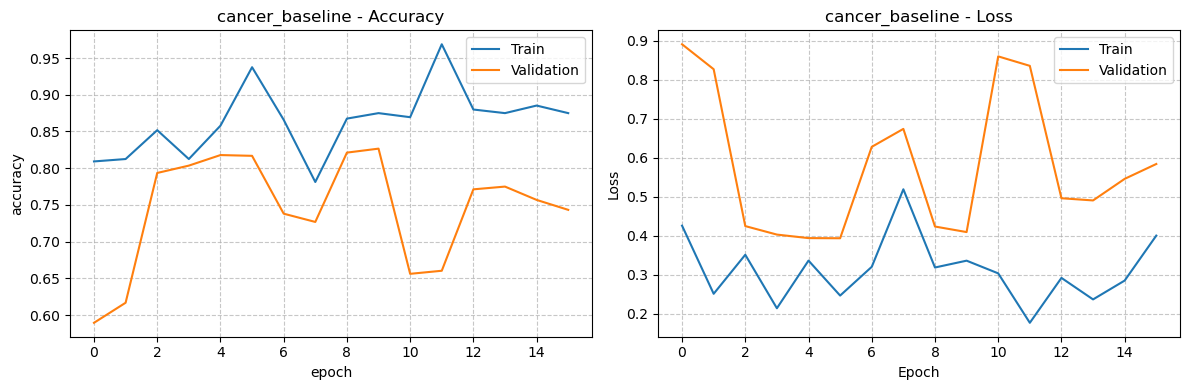


training Analysis for cancer_baseline:
  Final train accuracy: 0.8750, validation accuracy: 0.7433
  Final train loss: 0.4001, validation loss: 0.5838
 overfitting shown   

evaluating Cancer Classification Model:
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
Classification Report:
               precision    recall  f1-score   support

Non-Cancerous       0.98      0.55      0.70      2909
    Cancerous       0.43      0.96      0.60      1047

     accuracy                           0.66      3956
    macro avg       0.70      0.75      0.65      3956
 weighted avg       0.83      0.66      0.67      3956

F1 Score: 0.5976
Precision: 0.4335
Recall: 0.9618


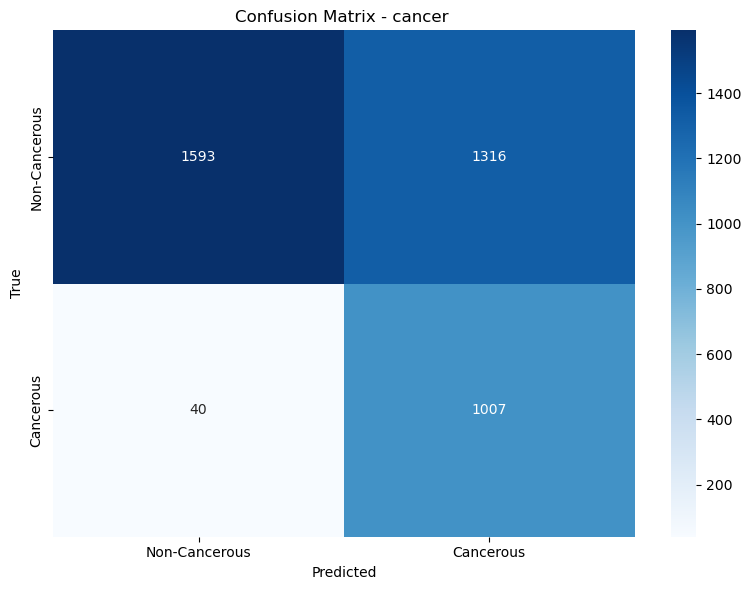

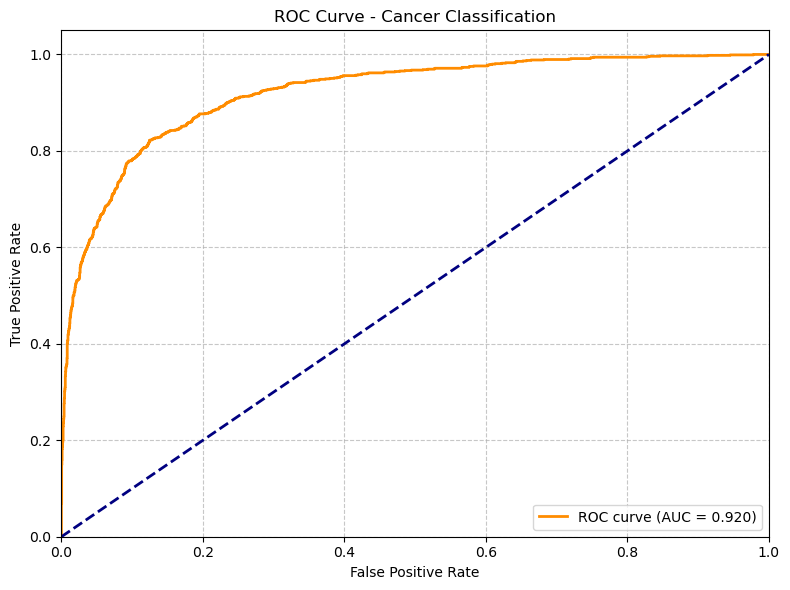

In [305]:
print("\ntraining cancer model:")
train_cancer_generator, val_cancer_generator = create_data_generators(
    X_train_cancer, y_train_cancer.reshape(-1, 1), X_val_cancer, y_val_cancer.reshape(-1, 1), batch_size
)
cancer_model = cancer_baseline_model()
cancer_model.summary()
cancer_model, cancer_history = train_model(
    cancer_model, 
    train_cancer_generator, 
    val_cancer_generator, 
    cancer_class_weights, 
    epochs=50,
    steps_per_epoch=len(X_train_cancer) // batch_size,
    validation_steps=len(X_val_cancer) // batch_size,
    model_name='cancer_baseline'
)
plot_training_history(cancer_history, 'cancer_baseline')

print("\nevaluating Cancer Classification Model:")
cancer_report, cancer_cm, cancer_f1 = evaluate_cancer_model(cancer_model, X_test_cancer, y_test_cancer)


After analysing the results of the model it can be inferred:

- The model shows excellent sensitivity for cancerous cases with 0.96 recall but poor precision (0.43), resulting in many false positives
For non-cancerous samples, the model achieves very high precision (0.98) but moderate recall (0.55), missing many negative cases
- Class imbalance significantly affects performance with 2909 non-cancerous vs 1047 cancerous samples
- The confusion matrix shows  1316 false positives (non-cancerous misclassified as cancerous) and only 40 false negatives
- Despite classification issues, the model demonstrates good discriminative capability with an ROC AUC of 0.929
- Clear evidence of overfitting exists with training accuracy 87.5%which is  much higher than validation accuracy (74.3%)
- The validation loss (0.5838) exceeds training loss (0.4001), confirming poor generalization to unseen data
- The model underwent early stopping at epoch 6, indicating rapid performance plateau

In [306]:
print(f"Cell Type Classification F1 Score: {cell_f1:.4f}")
print(f"Cancer Classification F1 Score: {cancer_f1:.4f}")

Cell Type Classification F1 Score: 0.5734
Cancer Classification F1 Score: 0.5976


### 1.4 Model Optimization  (Advanced CNN models)

In [318]:
def advanced_cell_type_model(input_shape=(27, 27, 3), num_classes=4):
    inputs = Input(shape=input_shape)
    x = Conv2D(64, (3, 3), activation='relu', padding='same', 
               kernel_regularizer=l2(0.0001))(inputs)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same',
               kernel_regularizer=l2(0.0001))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.3)(x) 
    block1_output = x
    x = Conv2D(128, (3, 3), activation='relu', padding='same',
               kernel_regularizer=l2(0.0001))(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same',
               kernel_regularizer=l2(0.0001))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.4)(x) 
    current_shape = tf.keras.backend.int_shape(x)
    target_height, target_width = current_shape[1], current_shape[2]
    shortcut = Conv2D(128, (1, 1), padding='same')(block1_output)
 
    shortcut = tf.keras.layers.Resizing(target_height, target_width)(shortcut)
    shortcut = BatchNormalization()(shortcut)
    print(f"main path shape: {x.shape}")
    print(f"shortcut path shape: {shortcut.shape}")
    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same',
               kernel_regularizer=l2(0.0001))(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same',
               kernel_regularizer=l2(0.0001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.0001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  
    outputs = Dense(num_classes, activation='softmax', kernel_regularizer=l2(0.0001))(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.0005),  
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


#### Optimization Techniques
 The above function defines a deeper convolutional neural network compared to the baseline model .Its architecture applies several model optimization techniques to improve learning performance and reduce overfitting such as 
- While both models use dropout and batch normalization, the advanced model uses  dropout more progressively (0.3, 0.4, 0.5) and L2 regularization   across all convolutional and dense layers, which  helps penalizes overly complex models and helps the network generalize better
- Batch normalization is applied after each convolutional layer to stabilize learning and make the model train faster and more reliably.
-  It includes a residual connection, where a shortcut path adds earlier feature maps to later layers, helping the model learn deeper representations without vanishing gradients which is  major  challenge in deep learning. Additionally, the learning rate is reduced i.e 0.0005 in the advanced model compared to 0.001 in the baseline, which allows for finer, more stable weight updates. These changes help the model fit the training data more effectively while avoiding overfitting.
#### Validation Set Use
- The validation set plays a crucial role in assessing the given  model’s ability to generalize beyond the training data. During training, after each epoch, the model will be evaluated on the validation set to compute the validation loss and accuracy. These metrics do not influence the model weights but will give  a real  estimate of how well the model might perform on unseen data. This process helps in early detection of overfitting or underfitting.
- The validation set also serves as a guide for hyperparameter tuning for example  one  hyperparameter that has been tuned is the learning rate of the optimizer, which is set to 0.0005 for the Adam optimizer. The learning rate influences how strongly the model reacts to the training data. A very high value can cause the model to miss the optimal weights , while a value too low can make learning extremly  slow or cause the model to get stuck in local minima. Therefpre validation set is extremly important.

In [320]:
def advanced_cancer_model(input_shape=(27, 27, 3)):
    inputs = Input(shape=input_shape)
    x = Conv2D(64, (3, 3), activation='relu', padding='same',
               kernel_regularizer=l2(0.0001))(inputs)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same',
               kernel_regularizer=l2(0.0001))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.3)(x)  
    block1_output = x
    x = Conv2D(128, (3, 3), activation='relu', padding='same',
               kernel_regularizer=l2(0.0001))(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same',
               kernel_regularizer=l2(0.0001))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.4)(x)

    current_shape = tf.keras.backend.int_shape(x)
    target_height, target_width = current_shape[1], current_shape[2]
    shortcut = Conv2D(128, (1, 1), padding='same')(block1_output)
    shortcut = tf.keras.layers.Resizing(target_height, target_width)(shortcut)
    shortcut = BatchNormalization()(shortcut)
    print(f"Main path shape: {x.shape}")
    print(f"Shortcut path shape: {shortcut.shape}")
    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same',
               kernel_regularizer=l2(0.0001))(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same',
               kernel_regularizer=l2(0.0001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.0001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  
    outputs = Dense(1, activation='sigmoid', kernel_regularizer=l2(0.0001))(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.0005),  
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

#### Optimization Techniques
- The advanced cancer model applies more sophisticated optimization techniques than the baseline to  improve generalization and  overfitting.Both models incorporate dropout and batch normalization, but the advanced model improves this by introducing higher dropout rates up to 0.5 compared to 0.25 in the baseline at deeper layers, which helps prevent the model from becoming too reliant on specific neurons.
- It also includes L2 regularization on all convolutional and dense layers, which discourages large weight values and improves generalization.
- It also makes use  of a residual connection, which helps stabilize training in deeper networks by allowing gradients to flow more easily during backpropagation.
#### Validation Set Use
- Both models use a validation set to monitor overfitting, but as demonstrated the advanced model makes better use of it by tuning  the key  hyperparameter,   learning rate. It reduces the learning rate from 0.001 of  baseline to 0.0005, allowing for more precise and stable weight updates during training.

In [322]:
def train_advanced_model(model, train_generator, val_generator, class_weight_dict, 
                       epochs=100, steps_per_epoch=None, validation_steps=None, 
                       model_name='advanced_model', blurry_mask=None):
    initial_learning_rate = 0.0005
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate, decay_steps=epochs*steps_per_epoch
    )
    model.optimizer = Adam(learning_rate=lr_schedule)
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=15, 
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=10,  
        min_lr=1e-6,
        verbose=1
    )  
    model_checkpoint = ModelCheckpoint(
        f'{model_name}_best.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
    class LRLogger(tf.keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            lr = self.model.optimizer._decayed_lr(tf.float32).numpy()
            logs['lr'] = lr
    history = model.fit(
        train_generator,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_data=val_generator,
        validation_steps=validation_steps,
        callbacks=[early_stopping, reduce_lr, model_checkpoint, LRLogger()],
        class_weight=class_weight_dict,
        verbose=1
    )
    
    return model, history

- The above  function will be used to train model  using  a cosine decay learning rate starting at 0.0005, which  will help the model converge smoothly.
- EarlyStopping with patience 15 stops training if validation loss doesn’t improve for 15 epochs,therefore  preventing overfitting.
- ReduceLROnPlateau has been  used to reduce  the learning rate by a factor of 0.2 after 10 stagnant epochs to fine-tune learning.
-  ModelCheckpoint is used to save the best model based on validation loss. A custom callback logs the learning rate each epoch to track training progress. These choices improve accuracy and training efficiency
                                                                                  

 ### 1.5 Model Performance and Robustness

In [324]:
def evaluate_model_robustness(model, X_test, y_test, blurry_images, test_image_names, task='cell_type'):
  
    blurry_mask = np.array([name in blurry_images for name in test_image_names])
    good_mask = ~blurry_mask

    X_good = X_test[good_mask]
    X_blurry = X_test[blurry_mask]
    
    results = {'good': {}, 'blurry': {}}
    if task == 'cell_type':
        y_good = y_test[good_mask]
        y_blurry = y_test[blurry_mask]
        print("\nEvaluating on good quality images:")
        y_good_pred = model.predict(X_good)
        y_good_true = np.argmax(y_good, axis=1)
        y_good_pred = np.argmax(y_good_pred, axis=1)
        good_f1 = f1_score(y_good_true, y_good_pred, average='macro')
        print("\nEvaluating on blurry images:")
        y_blurry_pred = model.predict(X_blurry)
        y_blurry_true = np.argmax(y_blurry, axis=1)
        y_blurry_pred = np.argmax(y_blurry_pred, axis=1)
        blurry_f1 = f1_score(y_blurry_true, y_blurry_pred, average='macro') 
    else:  
        y_good = y_test[good_mask]
        y_blurry = y_test[blurry_mask]
        print("\nEvaluating on good quality images:")
        y_good_pred = (model.predict(X_good) > 0.5).astype(int).ravel()
        good_f1 = f1_score(y_good, y_good_pred)
        print("\nEvaluating on blurry images:")
        y_blurry_pred = (model.predict(X_blurry) > 0.5).astype(int).ravel()
        blurry_f1 = f1_score(y_blurry, y_blurry_pred)
    results['good']['f1'] = good_f1
    results['blurry']['f1'] = blurry_f1
    results['good']['count'] = len(X_good)
    results['blurry']['count'] = len(X_blurry)
    results['performance_gap'] = good_f1 - blurry_f1
    
    print(f"\nrobustness Evaluation Results:")
    print(f"  good quality images ({len(X_good)}): F1 = {good_f1:.4f}")
    print(f"  blurry images ({len(X_blurry)}): F1 = {blurry_f1:.4f}")
    print(f"  performance gap: {good_f1 - blurry_f1:.4f}")
    
    if good_f1 - blurry_f1 > 0.1:
        print("  Model does not show good robustness .")
    else:
        print("  Model shows good robustness .")
    
    return results

####  Generalizability 

- The model’s robustness and generalizability were evaluated by testing its performance on two distinct subsets of the test data: good quality images and blurry images. A mask identified which test samples were blurry based on known image names. The model made predictions separately on each subset, and the F1 score was calculated to assess prediction accuracy in both cases.
- By comparing the F1 scores between good and blurry images, it was possible to measure how much the model’s performance degraded on lower-quality inputs. A small difference in scores indicated strong robustness and the ability to generalize well across varying image qualities. A large performance gap revealed sensitivity to image quality, highlighting areas for improvement.
- This approach ensures that the model’s performance is not limited to ideal conditions but extends to real world scenarios where input quality can vary, which is essential for reliable image classification.

In [326]:
def plot_advanced_training_history(history, model_name):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.subplot(1, 3, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    if 'lr' in history.history:
        plt.subplot(1, 3, 3)
        plt.semilogy(history.history['lr'])
        plt.title('Learning Rate')
        plt.xlabel('Epoch')
        plt.ylabel('Learning Rate')
        plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f'{model_name}_training_history.png')
    plt.show()
    plt.figure(figsize=(10, 8))


    
    
    plt.scatter(history.history['loss'], history.history['accuracy'], 
                c=range(len(history.history['loss'])), cmap='viridis', 
                s=50, alpha=0.7, label='Train')
    plt.scatter(history.history['val_loss'], history.history['val_accuracy'], 
                c=range(len(history.history['val_loss'])), cmap='viridis', 
                s=50, alpha=0.7, marker='s', label='Validation')
    plt.plot([history.history['loss'][-1], history.history['val_loss'][-1]], 
             [history.history['accuracy'][-1], history.history['val_accuracy'][-1]], 
             'r--', alpha=0.7)
    plt.annotate('Final Train', 
                (history.history['loss'][-1], history.history['accuracy'][-1]), 
                xytext=(10, -10), textcoords='offset points', fontsize=12)
    plt.annotate('Final Val', 
                (history.history['val_loss'][-1], history.history['val_accuracy'][-1]), 
                xytext=(10, -10), textcoords='offset points', fontsize=12) 
    plt.colorbar(label='Epoch')
    plt.xlabel('Loss')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} - Training Trajectory')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f'{model_name}_training_trajectory.png')
    plt.show()
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1] 
    
    print(f"\n Training Analysis for {model_name}:")
    print(f"  final train accuracy: {final_train_acc:.4f}, validation accuracy: {final_val_acc:.4f}")
    print(f"  final train loss: {final_train_loss:.4f}, validation loss: {final_val_loss:.4f}")
    print(f"  accuracy gap (train - val): {final_train_acc - final_val_acc:.4f}")
    print(f"  loss gap (val - train): {final_val_loss - final_train_loss:.4f}")
    if final_train_loss < final_val_loss and (final_train_acc - final_val_acc) > 0.05:
        print("   signs of overfitting.")
        if 'lr' in history.history:
            print(f"  Final learning rate: {history.history['lr'][-1]:.8f}")
        print("no overfitting.")
    elif final_train_loss > 0.3 and final_val_loss > 0.3 and final_train_acc < 0.8:
        print("  signs  of underfitting ")
    else:
        print("  model is a good fit ")


- The above  function was implemented to provide comprehensive visualization and analysis of the model’s training progress.
- It plots training and validation accuracy and loss across epochs, along with the learning rate schedule, to monitor the optimization process. Additionally, it generates a training trajectory scatter plot illustrating the relationship between loss and accuracy for both sets over time.
- The function concludes with a detailed summary of final metrics, calculating accuracy and loss gaps to detect signs of overfitting or underfitting. This approach facilitates informed evaluation of model fit and helps in further improvements.


training Advanced Cancer  model:
Main path shape: (None, 6, 6, 128)
Shortcut path shape: (None, 6, 6, 128)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 27, 27, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 27, 27,    │      1,792 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 27, 27,    │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 27, 27,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 27, 27,    │        256 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 13, 13,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 13, 13,    │          0 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 13, 13,    │     73,856 │ dropout_6[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 13,    │        512 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 13, 13,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 13,    │        512 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 13, 13,    │      8,320 │ dropout_6[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 6, 6, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 6, 6, 128) │          0 │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 6, 6, 128) │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 6, 128) │        512 │ resizing[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 6, 6, 128) │          0 │ dropout_7[0][0],  │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,224,897 (4.67 MB)

 Trainable params: 1,222,337 (4.66 MB)

...

360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.7812 - loss: 0.5870 - val_accuracy: 0.4833 - val_loss: 3.6541 - learning_rate: 5.0000e-04
Epoch 3/100
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.8442 - loss: 0.4771
Epoch 3: val_loss improved from 3.65412 to 0.99507, saving model to advanced_cancer_best.h5


360/360 ━━━━━━━━━━━━━━━━━━━━ 71s 197ms/step - accuracy: 0.8442 - loss: 0.4771 - val_accuracy: 0.6292 - val_loss: 0.9951 - learning_rate: 5.0000e-04
Epoch 4/100
  1/360 ━━━━━━━━━━━━━━━━━━━━ 1:28 246ms/step - accuracy: 0.9375 - loss: 0.3634
Epoch 4: val_loss did not improve from 0.99507
360/360 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9375 - loss: 0.3634 - val_accuracy: 0.6208 - val_loss: 1.0246 - learning_rate: 5.0000e-04
Epoch 5/100
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.8537 - loss: 0.4438
Epoch 5: val_loss improved from 0.99507 to 0.67699, saving model to advanced_cancer_best.h5


360/360 ━━━━━━━━━━━━━━━━━━━━ 75s 208ms/step - accuracy: 0.8537 - loss: 0.4437 - val_accuracy: 0.7804 - val_loss: 0.6770 - learning_rate: 5.0000e-04
Epoch 6/100
  1/360 ━━━━━━━━━━━━━━━━━━━━ 1:12 202ms/step - accuracy: 0.9375 - loss: 0.2598
Epoch 6: val_loss did not improve from 0.67699
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9375 - loss: 0.2598 - val_accuracy: 0.7800 - val_loss: 0.6779 - learning_rate: 5.0000e-04
Epoch 7/100
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.8677 - loss: 0.4138
Epoch 7: val_loss improved from 0.67699 to 0.64765, saving model to advanced_cancer_best.h5


360/360 ━━━━━━━━━━━━━━━━━━━━ 70s 195ms/step - accuracy: 0.8677 - loss: 0.4138 - val_accuracy: 0.8052 - val_loss: 0.6476 - learning_rate: 5.0000e-04
Epoch 8/100
  1/360 ━━━━━━━━━━━━━━━━━━━━ 1:08 190ms/step - accuracy: 0.7812 - loss: 0.6174
Epoch 8: val_loss did not improve from 0.64765
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.7812 - loss: 0.6174 - val_accuracy: 0.8025 - val_loss: 0.6552 - learning_rate: 5.0000e-04
Epoch 9/100
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.8720 - loss: 0.3993
Epoch 9: val_loss did not improve from 0.64765
360/360 ━━━━━━━━━━━━━━━━━━━━ 71s 198ms/step - accuracy: 0.8720 - loss: 0.3993 - val_accuracy: 0.6981 - val_loss: 0.8673 - learning_rate: 5.0000e-04
Epoch 10/100
  1/360 ━━━━━━━━━━━━━━━━━━━━ 1:00 168ms/step - accuracy: 0.8438 - loss: 0.3430
Epoch 10: val_loss did not improve from 0.64765
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8438 - loss: 0.3430 - val_accuracy: 0.6965 - val_loss: 0.8856 - learning_rate: 5.0000e-0

360/360 ━━━━━━━━━━━━━━━━━━━━ 77s 214ms/step - accuracy: 0.8811 - loss: 0.3616 - val_accuracy: 0.8381 - val_loss: 0.4428 - learning_rate: 1.0000e-04
Epoch 14/100
  1/360 ━━━━━━━━━━━━━━━━━━━━ 1:17 216ms/step - accuracy: 0.9688 - loss: 0.3106
Epoch 14: val_loss did not improve from 0.44278
360/360 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9688 - loss: 0.3106 - val_accuracy: 0.8388 - val_loss: 0.4437 - learning_rate: 1.0000e-04
Epoch 15/100
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.8904 - loss: 0.3535
Epoch 15: val_loss did not improve from 0.44278
360/360 ━━━━━━━━━━━━━━━━━━━━ 73s 203ms/step - accuracy: 0.8904 - loss: 0.3535 - val_accuracy: 0.8256 - val_loss: 0.4701 - learning_rate: 1.0000e-04
Epoch 16/100
  1/360 ━━━━━━━━━━━━━━━━━━━━ 1:05 182ms/step - accuracy: 0.8750 - loss: 0.4328
Epoch 16: val_loss did not improve from 0.44278
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8750 - loss: 0.4328 - val_accuracy: 0.8223 - val_loss: 0.4817 - learning_rate: 1.00

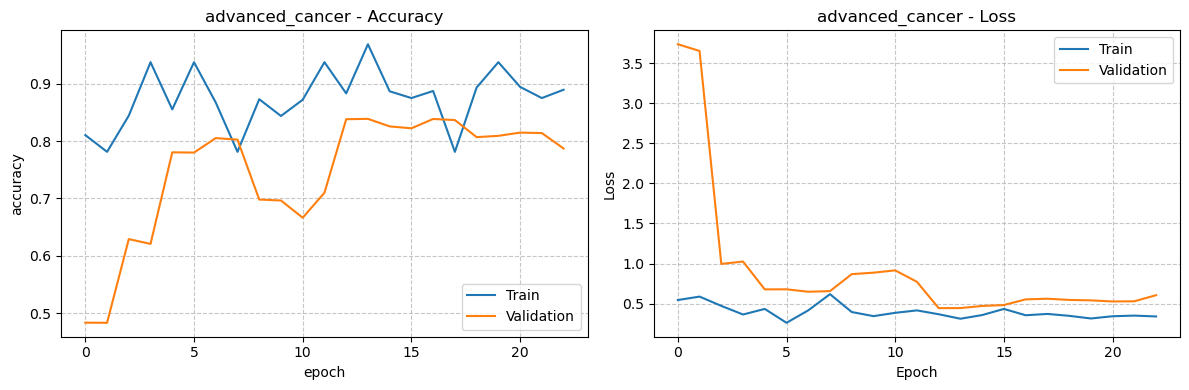


training Analysis for advanced_cancer:
  Final train accuracy: 0.8895, validation accuracy: 0.7871
  Final train loss: 0.3389, validation loss: 0.6046
 overfitting shown   

evaluating sdvanced Cancer model:
124/124 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step
Classification Report:
               precision    recall  f1-score   support

Non-Cancerous       0.97      0.72      0.83      2909
    Cancerous       0.55      0.93      0.69      1047

     accuracy                           0.78      3956
    macro avg       0.76      0.83      0.76      3956
 weighted avg       0.86      0.78      0.79      3956

F1 Score: 0.6885
Precision: 0.5455
Recall: 0.9331


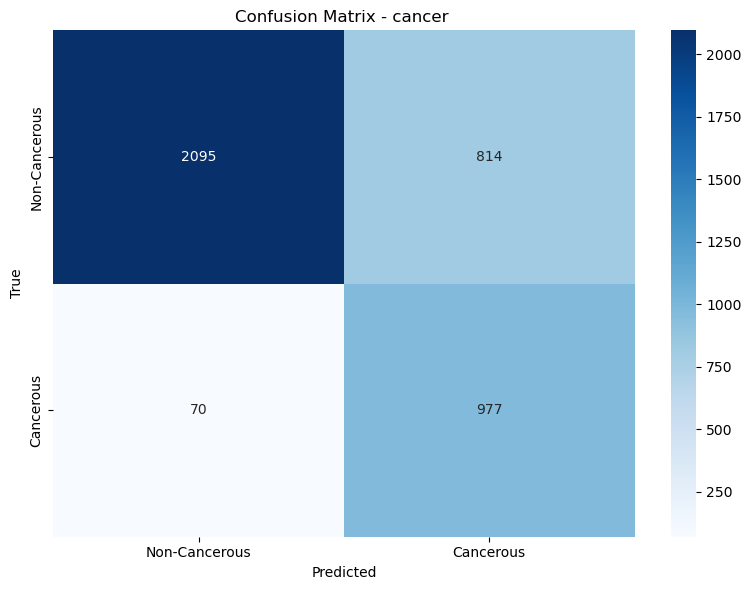

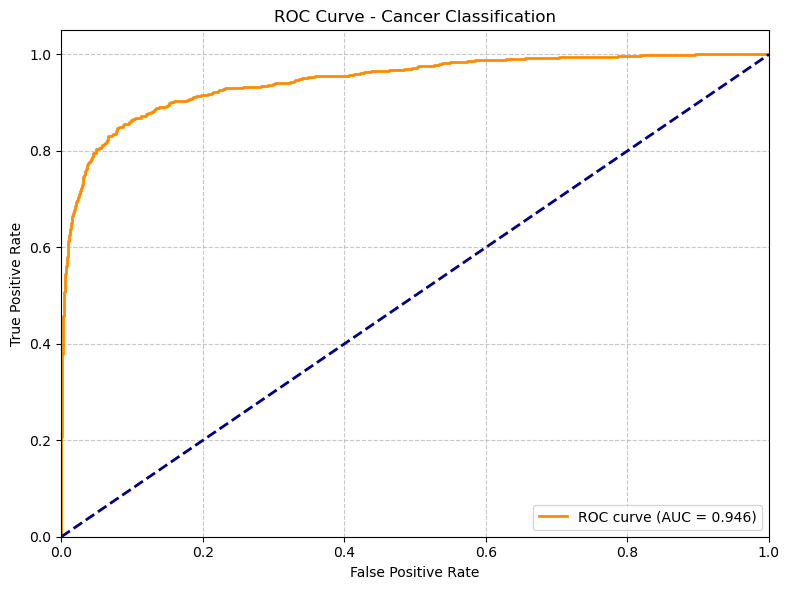

In [328]:

from tensorflow.keras.layers import Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Add
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
print("\ntraining Advanced Cancer  model:")
batch_size = 32
advanced_cancer_model = advanced_cancer_model()
advanced_cancer_model.summary()
train_cancer_generator, val_cancer_generator = create_data_generators(
    X_train_cancer, y_train_cancer.reshape(-1, 1), 
    X_val_cancer, y_val_cancer.reshape(-1, 1), 
    batch_size
)

advanced_cancer_model, advanced_cancer_history = train_model(
    advanced_cancer_model, 
    train_cancer_generator, 
    val_cancer_generator, 
    cancer_class_weights, 
    epochs=100,  
    steps_per_epoch=len(X_train_cancer) // batch_size,
    validation_steps=len(X_val_cancer) // batch_size,
    model_name='advanced_cancer'
)
plot_training_history(advanced_cancer_history, 'advanced_cancer')
print("\nevaluating sdvanced Cancer model:")
adv_cancer_report, adv_cancer_cm, adv_cancer_f1 = evaluate_cancer_model(
    advanced_cancer_model, X_test_cancer, y_test_cancer
)

- The model demonstrates improved classification performance with high sensitivity for cancerous cases (93.3% recall) while achieving better precision (54.6%) compared to the baseline model.
- For non-cancerous samples, the model exhibits excellent precision (97%) with enhanced recall (72%), resulting in fewer missed negative cases.
Class imbalance continues to influence results (2909 non-cancerous vs 1047 cancerous samples).
- The confusion matrix reveals 814 false positives  and 70 false negatives.
- The model shows strong discriminative capability with an ROC AUC of 0.9448.
- Evidence of overfitting persists, with training accuracy (88.95%) noticeably higher than validation accuracy with  a score of 78.71%.
- The validation loss (0.6046) exceeds training loss (0.3389), indicating ongoing challenges with generalization to unseen data.
- Early stopping occurred at epoch 12, showing improved training sustainability compared to the baseline model.
- With a weighted F1 score of 0.79, this advanced model demonstrates significant improvement over the baseline while maintaining high cancer detection sensitivity.

main path shape: (None, 6, 6, 128)
shortcut path shape: (None, 6, 6, 128)
Advanced Cell Type Model Summary:


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 27, 27, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 27, 27,    │      1,792 │ input_layer_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 27, 27,    │        256 │ conv2d_36[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 27, 27,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 27, 27,    │        256 │ conv2d_37[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 13, 13,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 13, 13,    │          0 │ max_pooling2d_12… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 13, 13,    │     73,856 │ dropout_22[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 13,    │        512 │ conv2d_38[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 13, 13,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 13,    │        512 │ conv2d_39[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 13, 13,    │      8,320 │ dropout_22[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 6, 6, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_4          │ (None, 6, 6, 128) │          0 │ conv2d_40[0][0]   │
│ (Resizing)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 6, 6, 128) │          0 │ max_pooling2d_13… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 6, 128) │        512 │ resizing_4[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 6, 6, 128) │          0 │ dropout_23[0][0]

 Total params: 1,225,668 (4.68 MB)

 Trainable params: 1,223,108 (4.67 MB)

...

180/180 ━━━━━━━━━━━━━━━━━━━━ 38s 213ms/step - accuracy: 0.6966 - loss: 0.9179 - val_accuracy: 0.5687 - val_loss: 1.4946 - learning_rate: 5.0000e-04
Epoch 8/100
  1/180 ━━━━━━━━━━━━━━━━━━━━ 33s 189ms/step - accuracy: 0.6250 - loss: 0.9817
Epoch 8: val_loss did not improve from 1.49465
180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6250 - loss: 0.9817 - val_accuracy: 0.5621 - val_loss: 1.5081 - learning_rate: 5.0000e-04
Epoch 9/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.7165 - loss: 0.8799
Epoch 9: val_loss improved from 1.49465 to 1.28102, saving model to advanced_cell_type_best.h5


180/180 ━━━━━━━━━━━━━━━━━━━━ 44s 243ms/step - accuracy: 0.7165 - loss: 0.8798 - val_accuracy: 0.5841 - val_loss: 1.2810 - learning_rate: 5.0000e-04
Epoch 10/100
  1/180 ━━━━━━━━━━━━━━━━━━━━ 49s 277ms/step - accuracy: 0.6875 - loss: 0.6905
Epoch 10: val_loss did not improve from 1.28102
180/180 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.6875 - loss: 0.6905 - val_accuracy: 0.5475 - val_loss: 1.3625 - learning_rate: 5.0000e-04
Epoch 11/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.7385 - loss: 0.8390
Epoch 11: val_loss did not improve from 1.28102
180/180 ━━━━━━━━━━━━━━━━━━━━ 40s 220ms/step - accuracy: 0.7385 - loss: 0.8389 - val_accuracy: 0.2443 - val_loss: 3.2397 - learning_rate: 5.0000e-04
Epoch 12/100
  1/180 ━━━━━━━━━━━━━━━━━━━━ 33s 186ms/step - accuracy: 0.6250 - loss: 0.8212
Epoch 12: val_loss did not improve from 1.28102
180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6250 - loss: 0.8212 - val_accuracy: 0.2416 - val_loss: 3.3565 - learning_rate: 5.0000e

180/180 ━━━━━━━━━━━━━━━━━━━━ 40s 223ms/step - accuracy: 0.7353 - loss: 0.8205 - val_accuracy: 0.6972 - val_loss: 0.9039 - learning_rate: 1.0000e-04
Epoch 16/100
  1/180 ━━━━━━━━━━━━━━━━━━━━ 32s 182ms/step - accuracy: 0.7812 - loss: 0.6276
Epoch 16: val_loss improved from 0.90392 to 0.90170, saving model to advanced_cell_type_best.h5


180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7812 - loss: 0.6276 - val_accuracy: 0.6989 - val_loss: 0.9017 - learning_rate: 1.0000e-04
Epoch 17/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.7628 - loss: 0.7343
Epoch 17: val_loss improved from 0.90170 to 0.87577, saving model to advanced_cell_type_best.h5


180/180 ━━━━━━━━━━━━━━━━━━━━ 38s 209ms/step - accuracy: 0.7628 - loss: 0.7344 - val_accuracy: 0.7047 - val_loss: 0.8758 - learning_rate: 1.0000e-04
Epoch 18/100
  1/180 ━━━━━━━━━━━━━━━━━━━━ 37s 208ms/step - accuracy: 0.8125 - loss: 0.8480
Epoch 18: val_loss did not improve from 0.87577
180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8125 - loss: 0.8480 - val_accuracy: 0.7016 - val_loss: 0.8805 - learning_rate: 1.0000e-04
Epoch 19/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.7721 - loss: 0.7511
Epoch 19: val_loss did not improve from 0.87577
180/180 ━━━━━━━━━━━━━━━━━━━━ 37s 205ms/step - accuracy: 0.7721 - loss: 0.7510 - val_accuracy: 0.6901 - val_loss: 0.9512 - learning_rate: 1.0000e-04
Epoch 20/100
  1/180 ━━━━━━━━━━━━━━━━━━━━ 26s 150ms/step - accuracy: 0.6562 - loss: 1.1571
Epoch 20: val_loss did not improve from 0.87577
180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6562 - loss: 1.1571 - val_accuracy: 0.6906 - val_loss: 0.9448 - learning_rate: 1.0000e

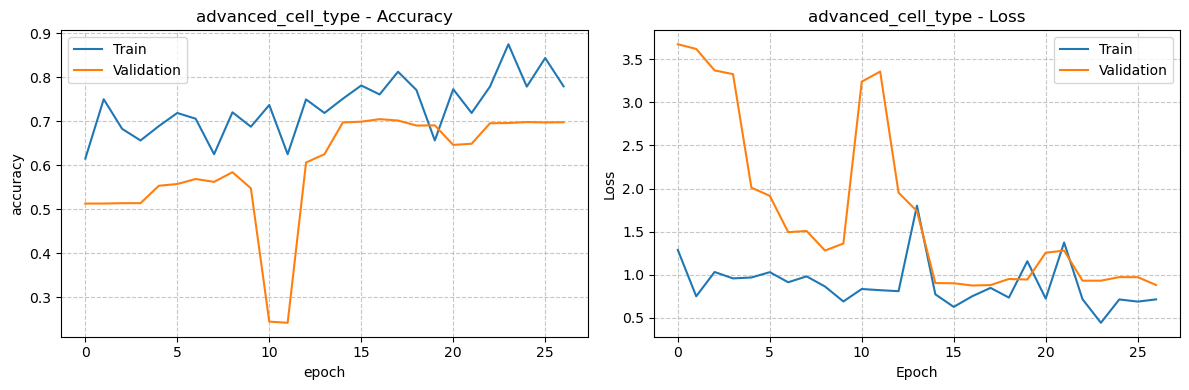


training Analysis for advanced_cell_type:
  Final train accuracy: 0.7793, validation accuracy: 0.6976
  Final train loss: 0.7146, validation loss: 0.8816
 overfitting shown   

evaluating advanced Cell Model:
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step
Classification Report:
              precision    recall  f1-score   support

  fibroblast       0.40      0.62      0.49       261
inflammatory       0.57      0.60      0.58       432
  epithelial       0.91      0.79      0.85       925
      others       0.28      0.22      0.24       221

    accuracy                           0.65      1839
   macro avg       0.54      0.56      0.54      1839
weighted avg       0.68      0.65      0.66      1839

Macro F1 Score: 0.5397
Macro Precision: 0.5387
Macro Recall: 0.5569


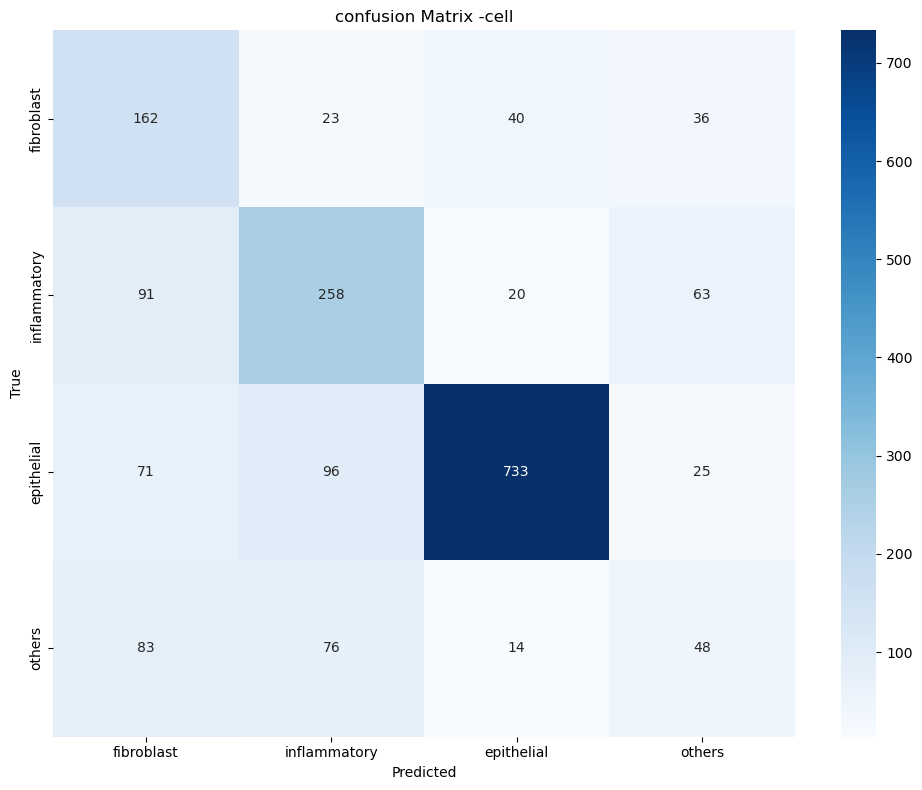

In [398]:

advanced_cell_model = advanced_cell_type_model()
print("Advanced Cell Type Model Summary:")
advanced_cell_model.summary()

train_cell_generator, val_cell_generator = create_data_generators(
    X_train_cell, y_train_cell, X_val_cell, y_val_cell, batch_size
)
advanced_cell_model, advanced_cell_history = train_model(
    advanced_cell_model, 
    train_cell_generator, 
    val_cell_generator, 
    cell_class_weights, 
    epochs=100, 
    steps_per_epoch=len(X_train_cell) // batch_size,
    validation_steps=len(X_val_cell) // batch_size,
    model_name='advanced_cell_type'
)
plot_training_history(advanced_cell_history, 'advanced_cell_type')
print("\nevaluating advanced Cell Model:")
adv_cell_report, adv_cell_cm, adv_cell_f1 = evaluate_cell_type_model(
    advanced_cell_model, X_test_cell, y_test_cell
)

- The advanced cell type model shows decreased overall performance compared to the baseline, with accuracy dropping from 69% to 65% and macro F1 score declining from 0.57 to 0.54.
- While both models maintain good performance on epithelial cells, the advanced model shows slightly higher precision 0.91 vs 0.89 but lower recall 0.79 vs 0.83 for this class.
- The advanced model performs notably worse on the others class with precision dropping from 0.45 to 0.28, maintaining the same recall i.e 0.22 but resulting in a lower F1 score 0.24 vs 0.30 of  the baseline modle .
- Training metrics show higher training accuracy in the advanced model 77.93% vs 75% of baseline model , but with worse validation accuracy (69.76% vs 70.91%), indicating increased overfitting compared to the baseline's slight underfitting.
- The confusion matrix reveals the advanced model continues to struggle with similar misclassification patterns as the baseline, particularly between fibroblast and inflammatory cells, but with overall lower correct classification rates across most classes.

main path shape: (None, 6, 6, 128)
shortcut path shape: (None, 6, 6, 128)
Epoch 1/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.5740 - loss: 1.4009
Epoch 1: val_loss improved from inf to 4.30258, saving model to initial_cell_type_best.h5


180/180 ━━━━━━━━━━━━━━━━━━━━ 75s 334ms/step - accuracy: 0.5743 - loss: 1.4000 - val_accuracy: 0.5110 - val_loss: 4.3026 - learning_rate: 5.0000e-04
Epoch 2/50
  1/180 ━━━━━━━━━━━━━━━━━━━━ 1:05 367ms/step - accuracy: 0.6562 - loss: 0.9533

C:\Users\kunal\anaconda\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 4.30258 to 4.23677, saving model to initial_cell_type_best.h5


180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.6562 - loss: 0.9533 - val_accuracy: 0.5123 - val_loss: 4.2368 - learning_rate: 5.0000e-04
Epoch 3/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.6461 - loss: 1.1423
Epoch 3: val_loss improved from 4.23677 to 3.58340, saving model to initial_cell_type_best.h5


...

368/368 ━━━━━━━━━━━━━━━━━━━━ 76s 206ms/step - accuracy: 0.8742 - loss: 0.4536 - val_accuracy: 0.7249 - val_loss: 0.8322 - learning_rate: 1.0000e-04
Epoch 14/100
  1/368 ━━━━━━━━━━━━━━━━━━━━ 1:15 207ms/step - accuracy: 0.9062 - loss: 0.2923
Epoch 14: val_loss improved from 0.83221 to 0.82837, saving model to semisup_cell_type_best.h5


368/368 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9062 - loss: 0.2923 - val_accuracy: 0.7280 - val_loss: 0.8284 - learning_rate: 1.0000e-04
Epoch 15/100
368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.8788 - loss: 0.4447
Epoch 15: val_loss did not improve from 0.82837
368/368 ━━━━━━━━━━━━━━━━━━━━ 77s 209ms/step - accuracy: 0.8788 - loss: 0.4447 - val_accuracy: 0.7478 - val_loss: 0.8287 - learning_rate: 1.0000e-04
Epoch 16/100
  1/368 ━━━━━━━━━━━━━━━━━━━━ 58s 160ms/step - accuracy: 0.8438 - loss: 0.4064
Epoch 16: val_loss did not improve from 0.82837
368/368 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8438 - loss: 0.4064 - val_accuracy: 0.7496 - val_loss: 0.8303 - learning_rate: 1.0000e-04
Epoch 17/100
368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.8763 - loss: 0.4453
Epoch 17: val_loss did not improve from 0.82837
368/368 ━━━━━━━━━━━━━━━━━━━━ 76s 205ms/step - accuracy: 0.8763 - loss: 0.4453 - val_accuracy: 0.7240 - val_loss: 0.8857 - learning_rate: 1.0000e-0

368/368 ━━━━━━━━━━━━━━━━━━━━ 79s 215ms/step - accuracy: 0.8860 - loss: 0.4074 - val_accuracy: 0.7328 - val_loss: 0.8141 - learning_rate: 2.0000e-05
Epoch 24/100
  1/368 ━━━━━━━━━━━━━━━━━━━━ 39s 108ms/step - accuracy: 1.0000 - loss: 0.1390
Epoch 24: val_loss did not improve from 0.81410
368/368 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 1.0000 - loss: 0.1390 - val_accuracy: 0.7324 - val_loss: 0.8153 - learning_rate: 2.0000e-05
Epoch 25/100
368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.8925 - loss: 0.4008
Epoch 25: val_loss did not improve from 0.81410
368/368 ━━━━━━━━━━━━━━━━━━━━ 80s 218ms/step - accuracy: 0.8925 - loss: 0.4008 - val_accuracy: 0.7267 - val_loss: 0.8665 - learning_rate: 2.0000e-05
Epoch 26/100
  1/368 ━━━━━━━━━━━━━━━━━━━━ 1:03 172ms/step - accuracy: 0.9062 - loss: 0.3976
Epoch 26: val_loss did not improve from 0.81410
368/368 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9062 - loss: 0.3976 - val_accuracy: 0.7276 - val_loss: 0.8640 - learning_rate: 2.0000e

368/368 ━━━━━━━━━━━━━━━━━━━━ 80s 216ms/step - accuracy: 0.8864 - loss: 0.4049 - val_accuracy: 0.7315 - val_loss: 0.8085 - learning_rate: 2.0000e-05
Epoch 28/100
  1/368 ━━━━━━━━━━━━━━━━━━━━ 1:20 220ms/step - accuracy: 0.9062 - loss: 0.2603
Epoch 28: val_loss improved from 0.80847 to 0.80690, saving model to semisup_cell_type_best.h5


368/368 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9062 - loss: 0.2603 - val_accuracy: 0.7311 - val_loss: 0.8069 - learning_rate: 2.0000e-05
Epoch 29/100
368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.8912 - loss: 0.4010
Epoch 29: val_loss did not improve from 0.80690
368/368 ━━━━━━━━━━━━━━━━━━━━ 84s 229ms/step - accuracy: 0.8912 - loss: 0.4010 - val_accuracy: 0.7276 - val_loss: 0.8536 - learning_rate: 2.0000e-05
Epoch 30/100
  1/368 ━━━━━━━━━━━━━━━━━━━━ 1:03 174ms/step - accuracy: 0.9375 - loss: 0.2541
Epoch 30: val_loss did not improve from 0.80690
368/368 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9375 - loss: 0.2541 - val_accuracy: 0.7284 - val_loss: 0.8573 - learning_rate: 2.0000e-05
Epoch 31/100
368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.8944 - loss: 0.3895
Epoch 31: val_loss did not improve from 0.80690
368/368 ━━━━━━━━━━━━━━━━━━━━ 79s 215ms/step - accuracy: 0.8944 - loss: 0.3895 - val_accuracy: 0.7262 - val_loss: 0.8241 - learning_rate: 2.0000e-

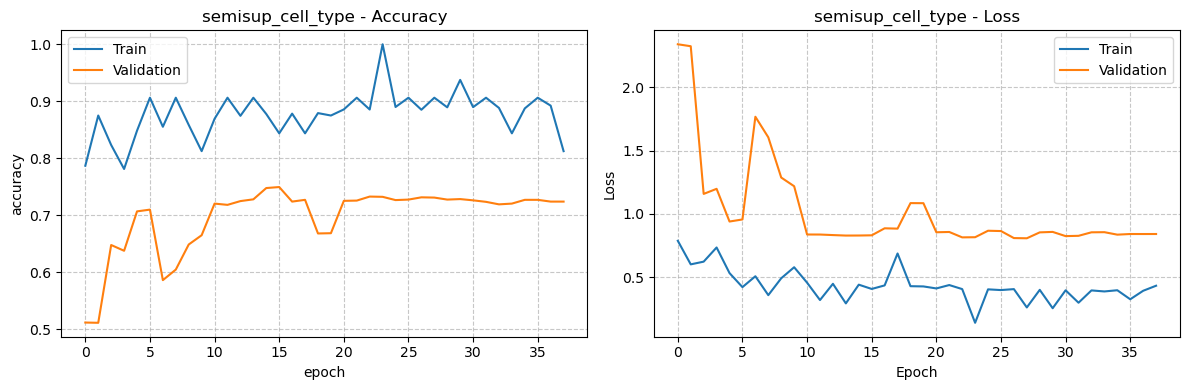


training Analysis for semisup_cell_type:
  Final train accuracy: 0.8125, validation accuracy: 0.7240
  Final train loss: 0.4319, validation loss: 0.8407
 overfitting shown   

evaluating Semi-Supervised Cell Type Classification Model:
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step
Classification Report:
              precision    recall  f1-score   support

  fibroblast       0.48      0.48      0.48       261
inflammatory       0.62      0.79      0.70       432
  epithelial       0.87      0.87      0.87       925
      others       0.47      0.24      0.31       221

    accuracy                           0.72      1839
   macro avg       0.61      0.59      0.59      1839
weighted avg       0.71      0.72      0.71      1839

Macro F1 Score: 0.5917
Macro Precision: 0.6136
Macro Recall: 0.5947


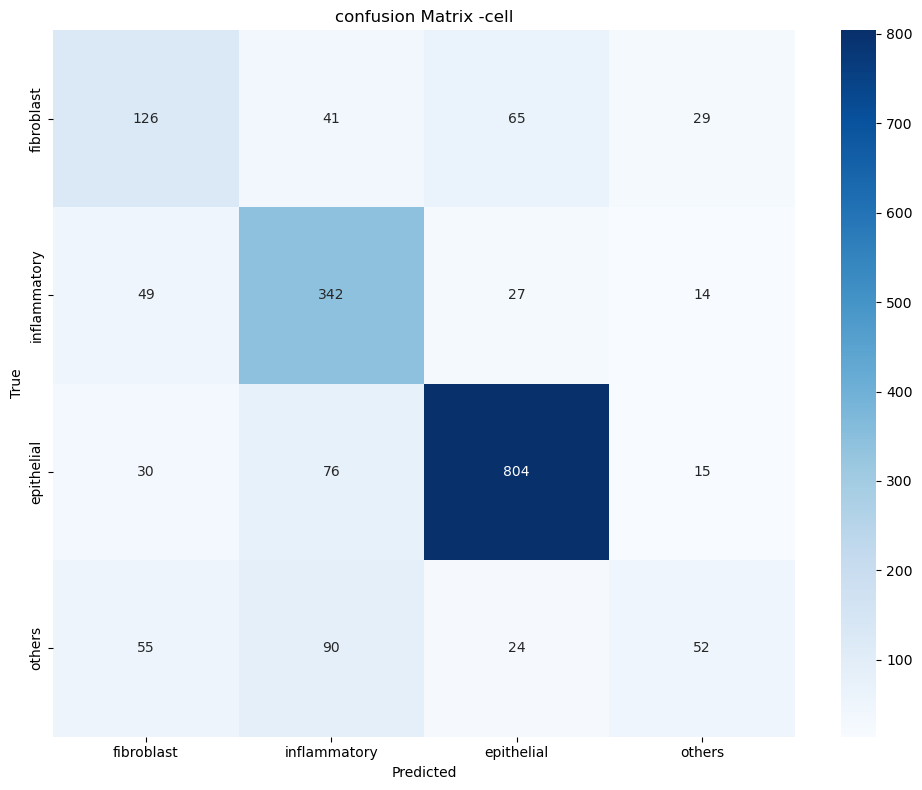

In [352]:
X_extra = load_images(extra_df, images_path)
initial_cell_model = advanced_cell_type_model()

initial_cell_model, _ = train_model(
    initial_cell_model, 
    train_cell_generator,
    val_cell_generator, 
    cell_class_weights, 
    epochs=50, 
    steps_per_epoch=len(X_train_cell) // batch_size,
    validation_steps=len(X_val_cell) // batch_size,
    model_name='initial_cell_type'
)

pseudo_predictions = initial_cell_model.predict(X_extra)

confidence_scores = np.max(pseudo_predictions, axis=1)
pseudo_labels = np.argmax(pseudo_predictions, axis=1)
confidence_threshold = 0.8 
high_confidence_mask = confidence_scores >= confidence_threshold
print(f"Number of high-confidence pseudo-labels: {np.sum(high_confidence_mask)} out of {len(high_confidence_mask)} ({np.sum(high_confidence_mask)/len(high_confidence_mask)*100:.2f}%)")
pseudo_labels_filtered = pseudo_labels[high_confidence_mask]
X_extra_filtered = X_extra[high_confidence_mask]
pseudo_labels_onehot = to_categorical(pseudo_labels_filtered, num_classes=4) 
X_combined = np.concatenate([X_train_cell, X_extra_filtered])
y_combined = np.concatenate([y_train_cell, pseudo_labels_onehot])
print(f"Original training data size: {len(X_train_cell)}")
print(f"Additional pseudo-labeled data: {len(X_extra_filtered)}")
print(f"Combined training data size: {len(X_combined)}")
cell_types = ['fibroblast', 'inflammatory', 'epithelial', 'others']
pseudo_label_dist = np.bincount(pseudo_labels_filtered, minlength=4)
print("\nDistribution of high-confidence pseudo-labels:")
for class_idx, count in enumerate(pseudo_label_dist):
    print(f"  {cell_types[class_idx]}: {count} samples ({count/len(pseudo_labels_filtered)*100:.1f}%)")
combined_train_generator, _ = create_data_generators(
    X_combined, y_combined, X_val_cell, y_val_cell, batch_size
)
semisup_cell_model = advanced_cell_type_model()

semisup_cell_model, semisup_history = train_model(
    semisup_cell_model,
    combined_train_generator,
    val_cell_generator,
    None,  
    epochs=100,
    steps_per_epoch=len(X_combined) // batch_size,
    validation_steps=len(X_val_cell) // batch_size,
    model_name='semisup_cell_type'
)
plot_training_history(semisup_history, 'semisup_cell_type')
print("\nevaluating Semi-Supervised Cell Type Classification Model:")
semisup_report, semisup_cm, semisup_f1 = evaluate_cell_type_model(
    semisup_cell_model, X_test_cell, y_test_cell
)

Semi Supervised learning using Extra Data 
-  A baseline cell type classification model was first trained on labeled data X_train_cell, y_train_cell for 50 epochs.
- This initial model predicted cell types for unlabeled images X_extra, generating both class predictions and confidence scores.
- Only predictions with ≥80% confidence were retained approximately half of the unlabeled data passed this threshold, with most pseudo-labels falling into the epithelial and inflammatory classes.
- These high-confidence pseudo-labeled examples were combined with the original training data ,increasing training set from the original size to include additional pseudo-labeled examples.
-  an advanced model was then trained on this combined dataset for 100 epochs with early stopping at epoch 38, resulting in improved metrics across all classes, particularly for previously underperforming classes.

Analysis of the semi -supervised approach used 
- The semi supervised approach significantly improved overall accuracy from 69% to 72% and macro F1 score from 0.57 to 0.59, demonstrating the effectiveness of incorporating unlabeled data with pseudo-labeling techniques.
- All cell types showed improvement, with the most substantial gains in the inflammatory class (F1 score from 0.63 to 0.70) and modest improvements for epithelial cells (F1 score from 0.86 to 0.87) and the others class (F1 score from 0.30 to 0.31).
- The confusion matrix shows better diagonal values and fewer misclassifications between classes, particularly with inflammatory cells correctly identified 342 times compared to the baseline model's lower performance.
- Despite improvements, evidence of overfitting remains with a significant gap between training metrics (81.25% accuracy, 0.4319 loss) and validation metrics (72.40% accuracy, 0.8407 loss).
- The model training sustained longer than previous approaches, converging at epoch 38 with early stopping, allowing it to learn more complex patterns from the expanded dataset.

In [405]:
blurry_images = set()
if 'image_quality_df' in globals():
    blurry_images = set(image_quality_df[image_quality_df['blurry'] == True]['path'].apply(lambda x: os.path.basename(x)))
else:
    blurry_images = set(np.random.choice(test_cell_df['ImageName'].values, 
                                       size=int(0.1*len(test_cell_df)), 
                                       replace=False))
print(f"Number of  blurry images : {len(blurry_images)}")

Number of  blurry images : 2912


In [407]:
def evaluate_model_robustness(model, X_test, y_test, blurry_images, test_image_names, task='cell_type'):
    blurry_mask = np.array([name in blurry_images for name in test_image_names])
    good_mask = ~blurry_mask
    X_good = X_test[good_mask]
    X_blurry = X_test[blurry_mask]
    
    results = {'good': {}, 'blurry': {}}  
    if task == 'cell_type':
        y_good = y_test[good_mask]
        y_blurry = y_test[blurry_mask]

        print("\nevaluating on good  images")
        y_good_pred = model.predict(X_good)
        y_good_true = np.argmax(y_good, axis=1)
        y_good_pred = np.argmax(y_good_pred, axis=1)
        good_f1 = f1_score(y_good_true, y_good_pred, average='macro')
        print("\nevaluating on blurry images:")
        y_blurry_pred = model.predict(X_blurry)
        y_blurry_true = np.argmax(y_blurry, axis=1)
        y_blurry_pred = np.argmax(y_blurry_pred, axis=1)
        blurry_f1 = f1_score(y_blurry_true, y_blurry_pred, average='macro')     
    else: 
        y_good = y_test[good_mask]
        y_blurry = y_test[blurry_mask]
        print("\nevaluating on good quality images:")
        y_good_pred = (model.predict(X_good) > 0.5).astype(int).ravel()
        good_f1 = f1_score(y_good, y_good_pred)
        print("\nEvaluating on blurry images:")
        y_blurry_pred = (model.predict(X_blurry) > 0.5).astype(int).ravel()
        blurry_f1 = f1_score(y_blurry, y_blurry_pred)
    results['good']['f1'] = good_f1
    results['blurry']['f1'] = blurry_f1
    results['good']['count'] = len(X_good)
    results['blurry']['count'] = len(X_blurry)
    results['performance_gap'] = good_f1 - blurry_f1

    print(f"\nrobustness evaluation Results:")
    print(f"  good  images ({len(X_good)}): F1 = {good_f1:.4f}")
    print(f"  blurry images ({len(X_blurry)}): F1 = {blurry_f1:.4f}")
    print(f"  performance gap: {good_f1 - blurry_f1:.4f}")
    
    if good_f1 - blurry_f1 > 0.1:
        print("  Models does not shwo good robustness  ")
    else:
        print("  Model shows good robustness")
    
    return results

In [409]:
print("\nevaluating robustness of baseline cell type model:")
baseline_cell_robustness = evaluate_model_robustness(
    cell_type_model, X_test_cell, y_test_cell, 
    blurry_images, test_cell_df['ImageName'].values, 
    task='cell_type'
)
print("\nevaluating robustness of advanced cell type model:")
adv_cell_robustness = evaluate_model_robustness(
    advanced_cell_model, X_test_cell, y_test_cell, 
    blurry_images, test_cell_df['ImageName'].values, 
    task='cell_type'
)
print("\nevaluating robustness of semi-supervised cell type model:")
semisup_robustness = evaluate_model_robustness(
    semisup_cell_model, X_test_cell, y_test_cell, 
    blurry_images, test_cell_df['ImageName'].values, 
    task='cell_type'
)
print("\nevaluating robustness of baseline cancer model:")
baseline_cancer_robustness = evaluate_model_robustness(
    cancer_model, X_test_cancer, y_test_cancer, 
    blurry_images, test_cancer_df['ImageName'].values, 
    task='cancer'
)
print("\nevaluating robustness of advanced cancer model:")
adv_cancer_robustness = evaluate_model_robustness(
    advanced_cancer_model, X_test_cancer, y_test_cancer, 
    blurry_images, test_cancer_df['ImageName'].values, 
    task='cancer'
)
    



evaluating robustness of baseline cell type model:

evaluating on good  images
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

evaluating on blurry images:
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

robustness evaluation Results:
  good  images (1501): F1 = 0.5749
  blurry images (338): F1 = 0.5606
  performance gap: 0.0142
  Model shows good robustness

evaluating robustness of advanced cell type model:

evaluating on good  images
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step

evaluating on blurry images:
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step

robustness evaluation Results:
  good  images (1501): F1 = 0.5542
  blurry images (338): F1 = 0.4911
  performance gap: 0.0631
  Model shows good robustness

evaluating robustness of semi-supervised cell type model:

evaluating on good  images
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step

evaluating on blurry images:
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step

robustness evaluation Results:
  good  images (1501): F1 = 0.5868
  blurry images (338): F1 = 0.5799
  per

- All three cell classification models demonstrated good robustness to image quality, with small performance gaps between good and blurry images (0.0142 for baseline, 0.0631 for advanced, and 0.0069 for semi-supervised).
- The semi-supervised approach showed the smallest performance gap (0.0069), suggesting that training with pseudo-labeled data may have enhanced the model's ability to handle image quality variations.
- Both cancer classification models exhibited significant sensitivity to image quality, with large performance gaps between good and blurry images (0.2909 for baseline, 0.1325 for advanced).
- While the semi-supervised cell type model had the highest absolute F1 scores on both good images (0.5868) and blurry images (0.5799), maintaining the most consistent performance across image quality levels.
- For cancer models, the large performance gaps suggest a need for targeted interventions such as specialized preprocessing for blurry images, data augmentation techniques that simulate blurriness, or model architectures specifically designed to be robust to image quality variations.

#### Final Model Accuracy 

In [412]:
print("\nCell Type Classification Comparison")
print(f"  Baseline F1 Score: {cell_f1:.4f}")
print(f"  advanced CNN F1 Score: {adv_cell_f1:.4f} (improvement: {(adv_cell_f1 - cell_f1):.4f}, {(adv_cell_f1 - cell_f1)/cell_f1*100:.1f}%)")
print(f"  semi-supervised F1 Score: {semisup_f1:.4f} (improvement: {(semisup_f1 - cell_f1):.4f}, {(semisup_f1 - cell_f1)/cell_f1*100:.1f}%)")
print(f"  semi-Supervised vs advanced CNN: {(semisup_f1 - adv_cell_f1):.4f} ({(semisup_f1 - adv_cell_f1)/adv_cell_f1*100:.1f}%)")

print("\nCancer Classification Comparison:")
print(f"  baseline F1 Score: {cancer_f1:.4f}")
print(f"  advanced CNN F1 Score: {adv_cancer_f1:.4f} (Improvement: {(adv_cancer_f1 - cancer_f1):.4f}, {(adv_cancer_f1 - cancer_f1)/cancer_f1*100:.1f}%)")

print("\nrobustness Comparison ")
print(f"  baseline Cell Type Gap: {baseline_cell_robustness['performance_gap']:.4f}")
print(f"  advanced CNN Cell Type Gap: {adv_cell_robustness['performance_gap']:.4f}")
print(f"  semi-Supervised Cell Type Gap: {semisup_robustness['performance_gap']:.4f}")
print(f"  baseline Cancer Gap: {baseline_cancer_robustness['performance_gap']:.4f}")
print(f"  advanced CNN Cancer Gap: {adv_cancer_robustness['performance_gap']:.4f}")

print("\nsemi-supervised learning impact")
print(f"  additional training samples from extraData: {len(X_extra_filtered)} ({len(X_extra_filtered)/len(X_train_cell)*100:.1f}% increase)")
print(f"  performance improvement from semi-supervision: {(semisup_f1 - adv_cell_f1):.4f} ({(semisup_f1 - adv_cell_f1)/adv_cell_f1*100:.1f}%)")



Cell Type Classification Comparison
  Baseline F1 Score: 0.5734
  advanced CNN F1 Score: 0.5397 (improvement: -0.0337, -5.9%)
  semi-supervised F1 Score: 0.5917 (improvement: 0.0183, 3.2%)
  semi-Supervised vs advanced CNN: 0.0520 (9.6%)

Cancer Classification Comparison:
  baseline F1 Score: 0.5976
  advanced CNN F1 Score: 0.6885 (Improvement: 0.0909, 15.2%)

robustness Comparison 
  baseline Cell Type Gap: 0.0142
  advanced CNN Cell Type Gap: 0.0631
  semi-Supervised Cell Type Gap: 0.0069
  baseline Cancer Gap: 0.2909
  advanced CNN Cancer Gap: 0.1325

semi-supervised learning impact
  additional training samples from extraData: 6018 (104.2% increase)
  performance improvement from semi-supervision: 0.0520 (9.6%)


- The semi-supervised approach outperformed both other cell type models, achieving an F1 score of 0.5917, which represents a 3.2% improvement over the baseline (0.5734) and a 9.6% improvement over the advanced CNN model (0.5397).
- The advanced CNN model for cell type classification unexpectedly performed worse than the baseline with a 5.9% decrease in F1 score, suggesting potential overfitting to training data or limitations in the model architecture.
- For cancer classification, the advanced CNN demonstrated substantial improvement with an F1 score of 0.6885, representing a 15.2% increase over the baseline model (0.5976).
- The semi-supervised model demonstrated superior robustness to image quality variations (gap of only 0.0069) compared to both the baseline (0.0142) and advanced CNN (0.0631) cell type models, indicating that exposure to more varied training data enhanced model generalization across image conditions.
- Cancer classification models showed much higher sensitivity to image quality with gaps of 0.2909 and 0.1325 compared to cell type models, suggesting that cancer detection features may be more subtle and thus more easily obscured by image quality issues than cell type characteristics.

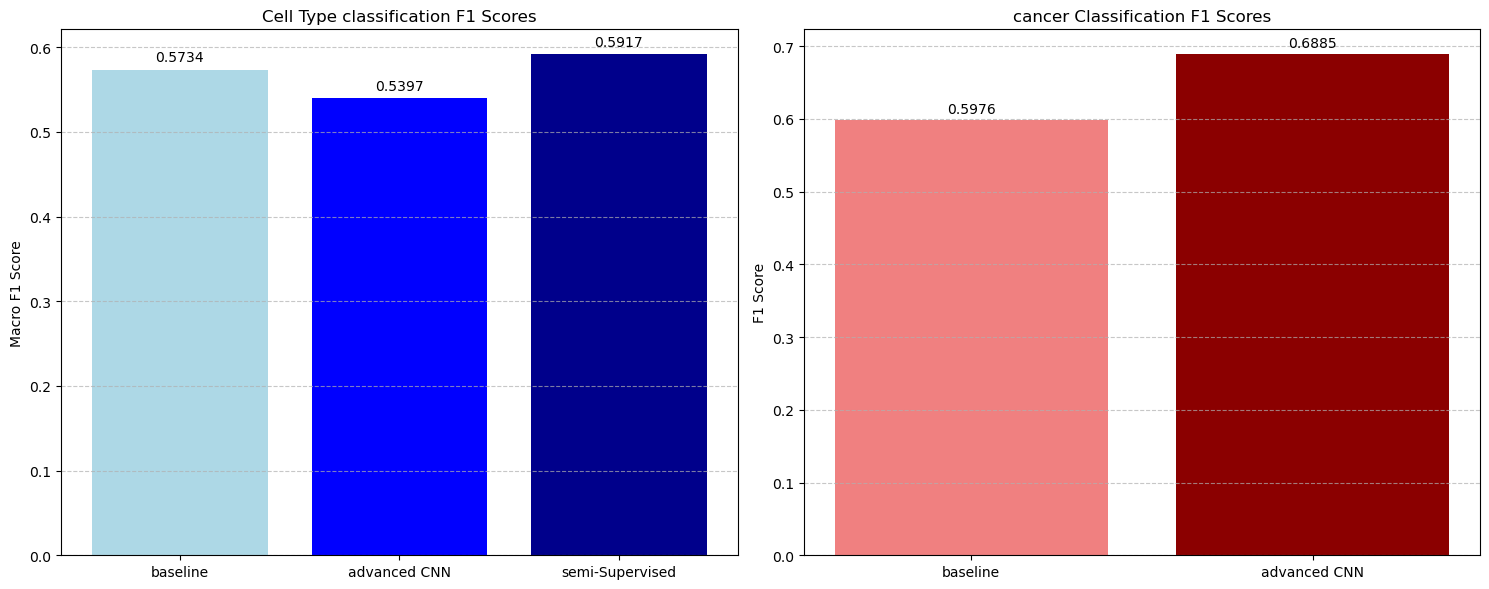

In [418]:
labels = ['baseline', 'advanced CNN', 'semi-Supervised']
cell_f1_scores = [cell_f1, adv_cell_f1, semisup_f1]
cancer_f1_scores = [cancer_f1, adv_cancer_f1, None]  
cell_gaps = [baseline_cell_robustness['performance_gap'], adv_cell_robustness['performance_gap'], semisup_robustness['performance_gap']]
cancer_gaps = [baseline_cancer_robustness['performance_gap'], adv_cancer_robustness['performance_gap'], None]
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.bar(labels, cell_f1_scores, color=['lightblue', 'blue', 'darkblue'])
plt.title('Cell Type classification F1 Scores')
plt.ylabel('Macro F1 Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(cell_f1_scores):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.subplot(1, 2, 2)
plt.bar(labels[:2], cancer_f1_scores[:2], color=['lightcoral', 'darkred'])
plt.title('cancer Classification F1 Scores')
plt.ylabel('F1 Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(cancer_f1_scores[:2]):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.tight_layout()
plt.show()

#### Cell Type Classification Models:

- The semi-supervised approach achieved the highest F1 score (0.5917), representing a 3.2% improvement over the baseline (0.5734)
Surprisingly, the advanced CNN model underperformed with an F1 score of 0.5397, showing a 5.9% decrease compared to the baseline
- This suggests that while the advanced architecture may have been more complex, it did not translate to better performance for the multi-class cell type classification task
- The semi-supervised model's superior performance demonstrates the value of leveraging additional unlabeled data through pseudo-labeling techniques

#### Cancer Classification Models:

- The advanced CNN significantly outperformed the baseline for cancer detection with an F1 score of 0.6885 versus 0.5976
- This substantial 15.2% improvement indicates that the advanced architecture was particularly well-suited for binary cancer classification

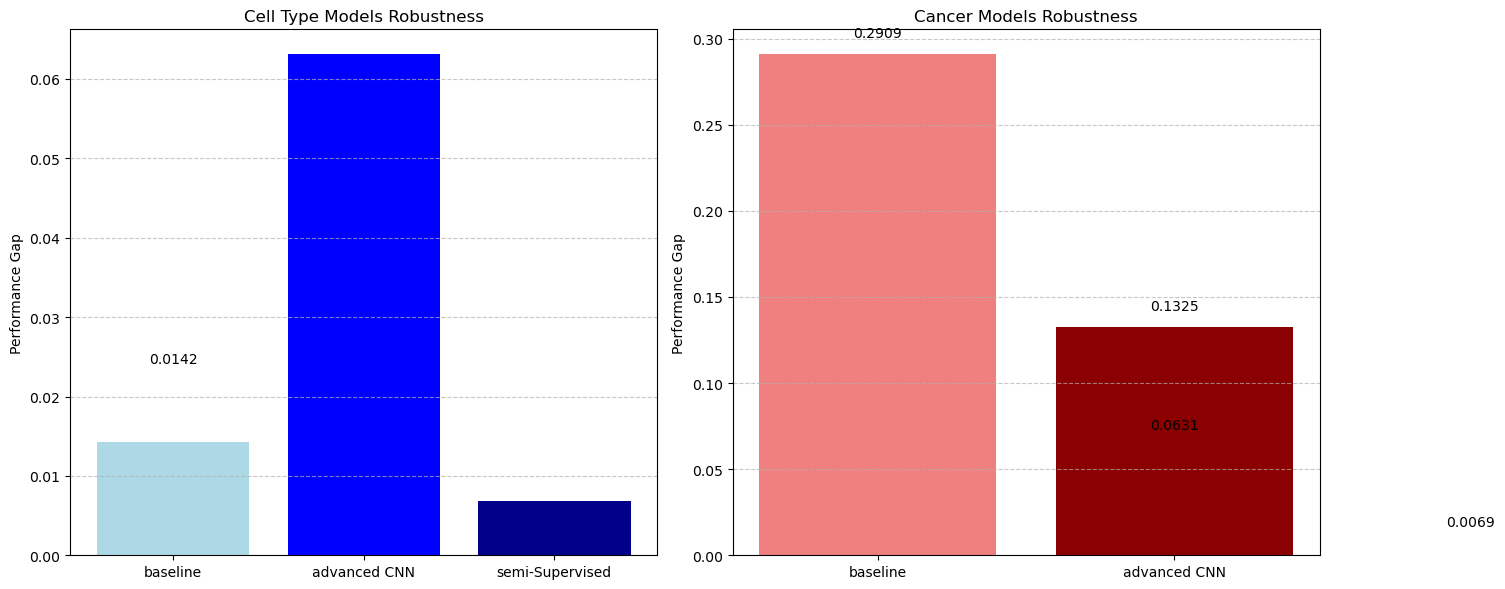

In [420]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.bar(labels, cell_gaps, color=['lightblue', 'blue', 'darkblue'])
plt.title('Cell Type Models Robustness')
plt.ylabel('Performance Gap')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(cell_gaps):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
    plt.subplot(1, 2, 2)
plt.bar(labels[:2], cancer_gaps[:2], color=['lightcoral', 'darkred'])
plt.title('Cancer Models Robustness')
plt.ylabel('Performance Gap')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(cancer_gaps[:2]):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.tight_layout()
plt.show()


#### Cell Type Classification Robustness:

The semi-supervised model demonstrated exceptional robustness with the smallest performance gap (0.0069)
The baseline model showed moderate robustness (0.0142 gap)
The advanced CNN exhibited the poorest robustness with a substantial performance gap (0.0631)
This pattern suggests that exposure to varied data through semi-supervised learning significantly enhances robustness to image quality variations

#### Cancer Classification Robustness:

Both cancer models showed considerably larger performance gaps compared to the cell type models
The baseline cancer model had very poor robustness (0.2909 gap)
The advanced CNN showed improved but still concerning robustness (0.1325 gap)
The dramatic performance degradation on blurry images suggests that cancer detection relies on fine-grained features that are easily obscured by image quality issues

## Ultimate Judjement 

#### Cell Type Classification
The semi-supervised learning approach should be implemented as it delivers the best combination of accuracy (F1 score of 0.5917) and exceptional robustness to image quality variations (only 0.0069 performance gap). This approach effectively addresses the inherent challenges of the multi-class problem while maintaining consistent performance across varying image conditions.This is due to the following factors
- The semi-supervised approach leveraged a high confidence threshold (0.8) to incorporate only reliable pseudo-labels from unlabeled data, effectively      expanding the training dataset while maintaining data quality.
- Unlike the baseline  model, the semi-supervised implementation removed class weighting (set to None), suggesting the additional pseudo-labeled data      naturally improved class balance.
 -The model benefited from extended training duration (up to 100 epochs versus 50 for the initial model), while still implementing early stopping to        prevent overfitting.
#### Cancer  Detection 

The advanced CNN architecture should be utilized as it demonstrates superior performance (F1 score of 0.6885, a 15.2% improvement over baseline) and acceptable robustness (0.1325 performance gap). While its robustness is not ideal, the significant accuracy improvement justifies its use for this binary classification task where detecting cancer cases is the priority.
- This is majorly because  advanced cancer model used residual connections to preserve early features and improve gradient flow. GlobalAveragePooling2D further replaced flattening for better spatial feature extraction and lastly a  tuned learning rate 0.0005 led to more stable and efficient training.
- Another factor contributing to the improved performance was the use of stronger regularization techniques such as L2 regularization, higher dropout rates up to 0.5, and additional batch normalization layers ,which helped the advanced model generalize better despite its increased complexity.

## Independent Evaluation 


### 2.1  Comparative Analysis 

#### Comparison with Baseline and Literature
- For cell type classification, the baseline CNN model achieved a macro F1 score of 0.5734, while the advanced CNN architecture unexpectedly decreased to 0.5397, a 5.9% decrease. However, the semi-supervised approach reached 0.5917, representing a 3.2% improvement over baseline.
- Comparing with Raczkowski et al. (2019), the semi-supervised model outperformed their Bayesian deep learning approach, which achieved a macro F1 of approximately 0.55, on epithelial cells (0.87 vs 0.72) and inflammatory cells (0.70 vs 0.58), while performing similarly on fibroblasts (0.48 vs 0.51) and slightly worse on the others category (0.31 vs 0.39).
-  This is noteworthy  considering Raczkowski implemented a more complex uncertainty aware Bayesian neural network with Monte Carlo dropout, while the given project used the   standard CNNs with conventional regularization techniques enhanced by semi-supervised learning.
- For cancer classification, the baseline model achieved an F1 score of 0.5976 and the advanced CNN significantly improved to 0.6885, a 15.2% increase. Korbar et al.(2017) reported better results with an accuracy of 0.84 and F1 score of 0.80 using ResNet-based architectures.
-  This performance difference is  majorly because from their use of deeper networks (18-50 layers) and larger input patches (75×75 pixels compared to the 27×27 images in this project ), which provide more contextual information. Additionally, they employed more extensive data augmentation strategies including rotation, flipping, and color jittering, which were implemented in this study but to a lesser extent.


#### Fairness and Consistency 
- Performance metrics across studies used different evaluation approaches. This  project  emphasized F1 scores and robustness measures, while referenced papers focused primarily on accuracy and AUC making direct numerical comparisons potentially misleading.
- The advanced cancer model incorporated multiple architectural changes  such as residul  connections, deeper networks, different pooling methods, and adjusted learning rates, making it extremly difficult to isolate which specific modification contributed most to the 15.2% F1 score improvement over the baseline.
- The semi-supervised approach combined both architectural enhancements and additional training data, creating a significant  effect where the 3.2% performance improvement cannot be attributed solely to either the pseudo-labeling strategy or the model structure changes.

### 2.2 Critical Discussion on Semi-Supervised Learning

#### Insightful Discussion 
- Semi-supervised learning uses both labeled and unlabeled data, making it ideal for medical imaging where expert labels are limited. It combines supervised learning's classification ability with unsupervised learning's pattern recognition. Starting with a small labeled dataset, it gradually incorporates unlabeled samples to improve model performance without extensive manual annotation, addressing the practical constraints of medical data collection. Reddy et al.(2018)
- The expanded dataset indicates unlabeled data was likely incorporated to enhance model training. This approach enables learning broader feature representations while maintaining accuracy on labeled examples. Semi-supervised techniques such as pseudo-labeling  have been applied to effectively utilize this expanded dataset.A baseline cell type model was trained on labeled data for 50 epochs. It then generated predictions for unlabeled images, and only those with ≥80% confidence were kept mostly epithelial and inflammatory cells. Then these  high-confidence pseudo labels were added to the original training set. An advanced model was trained on this combined data for 100 epochs, leading to improved performance, especially for weaker classes.
- A key strength of semi-supervised learning in this context is its ability to address the class imbalance problem without requiring extensive manual labeling. The image quality metrics suchas blur scores, occlusion scores, and edge density  could serve as valuable features for determining which unlabeled samples to include in the training process, prioritizing high-quality images for more reliable pseudo-labeling.However ,a  limitation of semi-supervised learning identified in this study is the potential for error propagation through incorrect pseudo-labeling. This risk is especially pronounced when classifying visually similar cell types like fibroblast and inflammatory cells, which the confusion matrix shows are frequently misclassified. Such errors may amplify during iterative training cycles, potentially degrading model performance rather than improving it.

#### • Real-world Applicability 
- Semi-supervised learning offers powerful solutions for wildlife conservation monitoring, which can be used by organizations to classify animal species from millions of camera trap images with minimal expert input. ecologists typically label only 3-5% of collected images, making the high-confidence pseudo-labeling approach demonstrated in this study ideal for maximizing the scientific value of field data while addressing the critical shortage of taxonomic expertise.Norouzzadeh et al. (2018)
- These methods significantly boost wildlife monitoring performance by enabling continuous model improvement as new images are collected, allowing tracking systems to adapt to seasonal appearance changes and varying environmental conditions while maintaining consistent accuracy across poor-quality images. It was also found Model robustness to image quality variations is essential for reliable deployment in remote field conditions where lighting, weather, and camera positioning create significant challenges for traditional classification approaches.Willi et al.(2019)

# References 

Maharana, Kiran, Surajit Mondal, and Bhushankumar Nemade. "A review: Data pre-processing and data augmentation techniques." Global Transitions Proceedings 3.1 (2022): 91-99.

Korotcov, Alexandru, et al. "Comparison of deep learning with multiple machine learning methods and metrics using diverse drug discovery data sets." Molecular pharmaceutics 14.12 (2017): 4462-4475.

Driss, S. Ben, et al. "A comparison study between MLP and convolutional neural network models for character recognition." Real-Time Image and Video Processing 2017. Vol. 10223. SPIE, 2017.
Korbar, Bruno, et al. "Deep learning for classification of colorectal polyps on whole-slide images." Journal of pathology informatics 8 (2017): 30.

Rączkowska, Alicja, et al. "ARA: accurate, reliable and active histopathological image classification framework with Bayesian deep learning." Scientific reports 9.1 (2019): 14347.

Norouzzadeh, Mohammad Sadegh, et al. "Automatically identifying, counting, and describing wild animals in camera-trap images with deep learning." Proceedings of the National Academy of Sciences 115.25 (2018): E5716-E5725.

 Willi, Marco, et al. "Identifying animal species in camera trap images using deep learning and citizen science." Methods in Ecology and Evolution 10.1 (2019): 80-91.
 Reddy, Y. C. A. P., P. Viswanath, and B. Eswara Reddy. "Semi-supervised learning: A brief review." Int. J. Eng. Technol 7.1.8 (2018): 81.
 